# Two-Level Global Portfolio Construction & Evaluation Framework


**Universe:** 7 Equity Indices · 6 Sovereign Bonds · 6 FX Pairs · 3 Commodities = **22 assets**  
**Study period:** January 2015 – December 2025 (2,413 trading days)  
**Levels:**
- **Level 1** — 9 strategies per equity index (EW / MV / HRP / RP × Buy-Hold / Monthly / Quarterly)
- **Level 2** — 6 global multi-asset strategies (G1 EW · G2 MV · G3 RP · G4 HRP · G4-VT · G5 Macro)

---


## Cell 1 · Install & Import Dependencies
  
Imports all required libraries and configures global plot settings.




In [ ]:
# ── Install scikit-learn if needed ───────────────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "scikit-learn"], check=False)

# ── Core imports ──────────────────────────────────────────────────────────────
import os, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from IPython.display import display, Image
from scipy.optimize import minimize
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
from sklearn.covariance import LedoitWolf
import sklearn

warnings.filterwarnings("ignore")
matplotlib.use("Agg")      # Agg backend: safe for Colab; images shown via display()

# ── Global plot style ─────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 150, "figure.facecolor": "white",
    "axes.facecolor": "#f9f9f9", "axes.grid": True, "grid.alpha": 0.4,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.family": "DejaVu Sans", "axes.titlesize": 12,
    "axes.labelsize": 10, "legend.fontsize": 8,
    "xtick.labelsize": 8, "ytick.labelsize": 8,
})

# ── Output directory ──────────────────────────────────────────────────────────
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"✅ All dependencies loaded")
print(f"   numpy      {np.__version__}")
print(f"   pandas     {pd.__version__}")
print(f"   sklearn    {sklearn.__version__}")
print(f"   output dir → {os.path.abspath(OUTPUT_DIR)}")


✅ All dependencies loaded
   numpy      2.0.2
   pandas     2.2.2
   sklearn    1.6.1
   output dir → /content/outputs


## Cell 2 · Asset-Class Definitions

Defines which tickers belong to each asset class.  
At **Level 2**, bonds, FX, and commodities are all treated as **investable return streams** — not just signals.  
VIX is explicitly excluded because it is a volatility index, not a tradeable return-generating asset.

**Expected output:** A printed summary of every asset group and the bond duration assumption.


In [ ]:
# ── Equity index names (must match CSV column/dataset keys) ──────────────────
EQUITY_INDICES = [
    "SP500", "Ibovespa", "EUROSTOXX50",
    "FTSE100", "JSETop40", "NIKKEI225", "ASX50",
]

# ── Macro series that become INVESTABLE at Level 2 ────────────────────────────
BOND_COLS = ["US_10Y", "DE_10Y", "UK_10Y", "JP_10Y", "AU_10Y", "ZA_10Y"]
FX_COLS   = ["EURUSD", "GBPUSD", "JPYUSD", "AUDUSD", "BRLUSD", "ZARUSD"]
COMM_COLS = ["Gold", "Oil", "Bitcoin"]   # VIX is signal-only, not investable

ALL_INVESTABLE_MACRO = BOND_COLS + FX_COLS + COMM_COLS

# Modified duration used to convert yield changes to approximate price returns:
#   r_bond ≈ -BOND_DURATION × Δyield / 100
BOND_DURATION = 7.0   # years — reasonable approximation for a 10Y government bond

# ── Summary ───────────────────────────────────────────────────────────────────
print("Asset-class definitions")
print(f"  Equity indices  ({len(EQUITY_INDICES)}): {EQUITY_INDICES}")
print(f"  Bond yields     ({len(BOND_COLS)}):  {BOND_COLS}")
print(f"  FX pairs        ({len(FX_COLS)}):  {FX_COLS}")
print(f"  Commodities     ({len(COMM_COLS)}):  {COMM_COLS}")
print(f"  Total investable macro assets: {len(ALL_INVESTABLE_MACRO)}")
print(f"  Bond duration assumption: {BOND_DURATION} years (modified duration)")
print(f"\n  ➡  Level-2 universe = {len(EQUITY_INDICES)} equity + {len(ALL_INVESTABLE_MACRO)} macro = {len(EQUITY_INDICES)+len(ALL_INVESTABLE_MACRO)} assets total")


Asset-class definitions
  Equity indices  (7): ['SP500', 'Ibovespa', 'EUROSTOXX50', 'FTSE100', 'JSETop40', 'NIKKEI225', 'ASX50']
  Bond yields     (6):  ['US_10Y', 'DE_10Y', 'UK_10Y', 'JP_10Y', 'AU_10Y', 'ZA_10Y']
  FX pairs        (6):  ['EURUSD', 'GBPUSD', 'JPYUSD', 'AUDUSD', 'BRLUSD', 'ZARUSD']
  Commodities     (3):  ['Gold', 'Oil', 'Bitcoin']
  Total investable macro assets: 15
  Bond duration assumption: 7.0 years (modified duration)

  ➡  Level-2 universe = 7 equity + 15 macro = 22 assets total


## Cell 3 · Data Loading

Loads the eight streamlined CSV files.  
- Loads data directly from  **GitHub raw URL**.  
  
- Data is trimmed to the study window (2014-2025), forward-filled for up to 5 missing days (holiday gaps), then any remaining NaNs are dropped.

**Expected output:** Eight `✅` lines confirming each dataset's row × column shape.


In [ ]:
def load_streamlined_datasets(data_dir="."):
    """
    Load all eight streamlined CSVs.
    Priority: local file → GitHub → synthetic fallback.
    """
    GITHUB_RAW_BASE = (
        "https://raw.githubusercontent.com/"
        "kboroz/MSFE_Capstone_Project/main/01_Data/Streamlined/"
    )
    file_map = {
        "SP500":       "streamlined_s&p_500.csv",
        "Ibovespa":    "streamlined_ibovespa.csv",
        "EUROSTOXX50": "streamlined_euro_stoxx_50.csv",
        "FTSE100":     "streamlined_ftse_100.csv",
        "JSETop40":    "streamlined_jse_top_40.csv",
        "NIKKEI225":   "streamlined_nikkei_225.csv",
        "ASX50":       "streamlined_asx_50.csv",
        "Macro":       "streamlined_macro.csv",
    }
    datasets, loaded = {}, []
    for name, fname in file_map.items():
        for src in [os.path.join(data_dir, fname), GITHUB_RAW_BASE + fname]:
            try:
                df = pd.read_csv(src, index_col=0, parse_dates=True)
                df = df.loc["2014-01-01":"2025-12-31"].ffill(limit=5).dropna()
                datasets[name] = df
                loaded.append(name)
                print(f"  ✅  {name:15s}  ({df.shape[0]} rows × {df.shape[1]} cols)")
                break
            except Exception:
                pass
        else:
            print(f"  ⚠️  {name}: not found — will use synthetic fallback.")
            datasets[name] = None
    if not loaded:
        print("\n  No real data — generating synthetic data for demonstration.")
        datasets = _simulate_datasets()
    return datasets


def _simulate_datasets():
    """Correlated GBM synthetic data when CSVs are unavailable."""
    np.random.seed(42)
    dates = pd.bdate_range("2015-01-05", "2021-12-30")
    n, dt = len(dates), 1/252
    params = {
        "SP500":(0.12,0.16,60), "Ibovespa":(0.08,0.22,56),
        "EUROSTOXX50":(0.06,0.18,46), "FTSE100":(0.04,0.15,60),
        "JSETop40":(0.05,0.19,31), "NIKKEI225":(0.07,0.17,60), "ASX50":(0.06,0.14,44),
    }
    datasets = {}
    for name,(mu,sigma,n_s) in params.items():
        common = np.random.normal((mu-0.5*0.12**2)*dt, 0.12*np.sqrt(dt), n)
        px = np.zeros((n, n_s))
        for j in range(n_s):
            idio = np.random.normal((mu-0.5*sigma**2)*dt, sigma*np.sqrt(dt), n)
            px[:,j] = 100 * np.exp(np.cumsum(0.6*common + 0.4*idio))
        datasets[name] = pd.DataFrame(px, index=dates,
                                       columns=[f"{name}_{j:03d}" for j in range(n_s)])
    macro_cols = ALL_INVESTABLE_MACRO + ["VIX"]
    datasets["Macro"] = pd.DataFrame(
        {c: 100*np.exp(np.cumsum(np.random.normal(0.0001,0.01,n))) for c in macro_cols},
        index=dates)
    return datasets


# ── Run the loader ────────────────────────────────────────────────────────────
print("[Cell 3] Loading datasets...")
all_datasets = load_streamlined_datasets(".")
_macro_raw   = all_datasets.get("Macro")
macro_df     = _macro_raw if (_macro_raw is not None and not _macro_raw.empty) else pd.DataFrame()
print(f"\n  Macro dataset columns: {macro_df.columns.tolist() if not macro_df.empty else 'N/A'}")


[Cell 3] Loading datasets...
  ✅  SP500            (2413 rows × 460 cols)
  ✅  Ibovespa         (2413 rows × 56 cols)
  ✅  EUROSTOXX50      (2413 rows × 46 cols)
  ✅  FTSE100          (2413 rows × 90 cols)
  ✅  JSETop40         (2413 rows × 31 cols)
  ✅  NIKKEI225        (2413 rows × 217 cols)
  ✅  ASX50            (2413 rows × 44 cols)
  ✅  Macro            (2413 rows × 23 cols)

  Macro dataset columns: ['AUDUSD', 'BRLUSD', 'Bitcoin', 'Oil', 'EURUSD', 'GBPUSD', 'Gold', 'JPYUSD', 'ZARUSD', 'ASX50', 'Ibovespa', 'FTSE100', 'SP500', 'JSE40', 'NIKKEI225', 'EUROSTOXX50', 'VIX', 'US_10Y', 'DE_10Y', 'UK_10Y', 'JP_10Y', 'AU_10Y', 'ZA_10Y']


## Cell 4 · Risk & Return Utility Functions

Defines all performance metrics used throughout the study.

| Metric | Formula |
|---|---|
| Sharpe Ratio | (E[r] - rf) / σ × √252 |
| Sortino Ratio | E[r] / σ_downside × √252 |
| Max Drawdown | min((NAV - peak) / peak) |
| Calmar Ratio | Ann. return / \|MDD\| |
| VaR 95% | 5th percentile of daily returns |
| CVaR 95% | Mean of returns ≤ VaR |
| Hit Rate | Fraction of days with r > 0 |
| Omega Ratio | Gains / Losses above zero threshold |
| Beta / Alpha | OLS vs G1 EW benchmark |
| Information Ratio | Ann(TE) / TE vol |

**Expected output:** A mini smoke-test confirming each function returns a sensible value.


In [ ]:
def compute_returns(prices):
    """Daily log returns: r_t = ln(P_t / P_{t-1})."""
    return np.log(prices / prices.shift(1)).dropna()

def annualise_return(ret, periods=252):  return ret.mean() * periods
def annualise_vol(ret, periods=252):     return ret.std() * np.sqrt(periods)

def sharpe_ratio(ret, rf=0.0, periods=252):
    ex = ret - rf/periods
    return ex.mean()/ex.std()*np.sqrt(periods) if ex.std()>0 else np.nan

def sortino_ratio(ret, rf=0.0, periods=252):
    ex = ret - rf/periods;  down = ex[ex<0].std()
    return ex.mean()/down*np.sqrt(periods) if down>0 else np.nan

def max_drawdown(ret):
    cum = (1+ret).cumprod()
    return ((cum - cum.cummax())/cum.cummax()).min()

def calmar_ratio(ret, periods=252):
    mdd = abs(max_drawdown(ret))
    return annualise_return(ret, periods)/mdd if mdd>0 else np.nan

def drawdown_series(ret):
    cum = (1+ret).cumprod();  return (cum - cum.cummax())/cum.cummax()

def var_95(ret):   return float(np.percentile(ret.dropna(), 5))
def cvar_95(ret):
    v = var_95(ret);  tail = ret[ret<=v]
    return float(tail.mean()) if len(tail)>0 else v

def hit_rate(ret):  return float((ret>0).mean())

def omega_ratio(ret, threshold=0.0):
    gains  = (ret[ret>threshold]-threshold).sum()
    losses = (threshold - ret[ret<threshold]).sum()
    return gains/losses if losses>0 else np.nan

def beta_alpha(ret, benchmark, periods=252):
    aligned = pd.concat([ret, benchmark], axis=1).dropna()
    if len(aligned)<30: return np.nan, np.nan
    r,b = aligned.iloc[:,0], aligned.iloc[:,1]
    cov = np.cov(r.values, b.values)
    beta  = cov[0,1]/cov[1,1] if cov[1,1]>0 else np.nan
    alpha = annualise_return(r,periods) - beta*annualise_return(b,periods)
    return beta, alpha

def information_ratio(ret, benchmark, periods=252):
    excess = ret - benchmark.reindex(ret.index).fillna(0)
    te = excess.std()*np.sqrt(periods)
    return annualise_return(excess,periods)/te if te>0 else np.nan

def compute_turnover(weights_df):
    """Daily portfolio turnover = sum of absolute weight changes."""
    return weights_df.diff().abs().sum(axis=1).fillna(0)

def apply_tc(gross_ret, turnover, c):
    """Net return after proportional round-trip TC: Net_r = Gross_r - c × Σ|Δw|."""
    return gross_ret - c*turnover

def performance_table(ret, label, turnover=None, benchmark=None,
                       cost_rates=(0.0, 0.005, 0.01, 0.02)):
    """Compile all metrics into a dict for one return series."""
    base = {
        "Strategy":            label,
        "Ann. Return (%)":     round(annualise_return(ret)*100, 2),
        "Ann. Volatility (%)": round(annualise_vol(ret)*100, 2),
        "Sharpe Ratio":        round(sharpe_ratio(ret), 3),
        "Sortino Ratio":       round(sortino_ratio(ret), 3),
        "Max Drawdown (%)":    round(max_drawdown(ret)*100, 2),
        "Calmar Ratio":        round(calmar_ratio(ret), 3),
        "VaR 95% (daily %)":   round(var_95(ret)*100, 3),
        "CVaR 95% (daily %)":  round(cvar_95(ret)*100, 3),
        "Hit Rate (%)":        round(hit_rate(ret)*100, 2),
        "Omega Ratio":         round(omega_ratio(ret), 3),
        "Mean Turnover":       round(turnover.mean(),4) if turnover is not None else np.nan,
    }
    if benchmark is not None:
        b, a = beta_alpha(ret, benchmark);  ir = information_ratio(ret, benchmark)
        base["Beta"]              = round(b,3)    if not np.isnan(b)  else np.nan
        base["Alpha (ann. %)"]    = round(a*100,2) if not np.isnan(a) else np.nan
        base["Information Ratio"] = round(ir,3)   if not np.isnan(ir) else np.nan
    if turnover is not None:
        for c in cost_rates:
            net = apply_tc(ret, turnover, c)
            base[f"Net Ret TC={round(c*100,1)}% (%)"] = round(annualise_return(net)*100, 2)
    return base

# ── Quick smoke test ──────────────────────────────────────────────────────────
np.random.seed(0)
_r = pd.Series(np.random.randn(500)*0.01 + 0.0003)
print("✅ Utility functions loaded — smoke test:")
print(f"   Sharpe  = {sharpe_ratio(_r):.3f}")
print(f"   Sortino = {sortino_ratio(_r):.3f}")
print(f"   Max DD  = {max_drawdown(_r)*100:.2f}%")
print(f"   VaR 95% = {var_95(_r)*100:.3f}%  |  CVaR 95% = {cvar_95(_r)*100:.3f}%")
print(f"   Hit Rate= {hit_rate(_r)*100:.2f}%  |  Omega = {omega_ratio(_r):.3f}")


✅ Utility functions loaded — smoke test:
   Sharpe  = 0.074
   Sortino = 0.125
   Max DD  = -27.45%
   VaR 95% = -1.586%  |  CVaR 95% = -2.032%
   Hit Rate= 49.20%  |  Omega = 1.012


## Cell 5 · Portfolio Weight Engines

Defines the four allocation methods used at both levels.

| Engine | Key property |
|---|---|
| `equal_weights` | 1/N for every asset — no estimation needed |
| `markowitz_weights` | Max-Sharpe with Ledoit-Wolf shrinkage — robust for N >> T |
| `risk_parity_weights` | Inverse-vol with vol-normalisation — prevents bond washout |
| `hrp_weights` | Two-tier HRP — handles heterogeneous multi-asset universes |

**Why Ledoit-Wolf?** With 460 stocks and a 252-day window the sample covariance is rank-deficient. LW shrinkage produces a full-rank, invertible matrix.  
**Why two-tier HRP?** Flat HRP on 22 assets over-weights equities because their internal correlation structure is richer. The two-tier fix applies HRP first at the asset-class level, then within each class.

**Expected output:** Weight vectors for each method on a small test dataset, confirming they sum to 1.0.


In [ ]:
def equal_weights(n):
    """1/N allocation — no estimation, zero turnover in static mode."""
    return np.ones(n)/n


def markowitz_weights(returns, rf=0.0, max_weight=None):
    """
    Maximum Sharpe Ratio portfolio with Ledoit-Wolf covariance shrinkage.

    max_weight auto-scales to min(3/N, 1.0) so the constraint is always
    feasible regardless of how many assets are in the universe.
    Four random Dirichlet restarts help avoid local optima.
    """
    n = returns.shape[1]
    if max_weight is None:
        max_weight = float(np.clip(3.0/n, 1.0/n, 1.0))

    mu    = returns.mean().values * 252
    lw    = LedoitWolf().fit(returns.values)
    Sigma = lw.covariance_ * 252

    def neg_sharpe(w):
        pv = w @ mu - rf;  ps = np.sqrt(w @ Sigma @ w)
        return -pv/ps if ps>1e-10 else 1e10

    constraints = [{"type":"eq","fun":lambda w: w.sum()-1}]
    bounds = [(0.0, max_weight)]*n
    best_res, best_val = None, np.inf
    for seed in [42,7,13,99]:
        np.random.seed(seed)
        res = minimize(neg_sharpe, np.random.dirichlet(np.ones(n)),
                       method="SLSQP", bounds=bounds, constraints=constraints,
                       options={"maxiter":2000,"ftol":1e-10})
        if res.success and res.fun < best_val:
            best_res, best_val = res, res.fun
    if best_res is not None:
        w = np.clip(best_res.x, 0.0, max_weight);  return w/w.sum()
    return equal_weights(n)


def risk_parity_weights(returns):
    """
    Inverse-volatility with vol-normalisation.

    Without normalisation, raw daily vols differ by 50× across asset classes
    (bonds 0.04% vs Bitcoin 3%), causing inverse-vol to collapse into a
    near-bond-only portfolio.  Rescaling all series to a common 10% annual
    vol target before computing weights fixes this.
    """
    TARGET_VOL = 0.10/np.sqrt(252)
    raw_vols   = returns.std().values.clip(1e-10)
    scale      = TARGET_VOL/raw_vols
    norm_vols  = (returns*scale).std().values.clip(1e-10)
    w = 1.0/norm_vols;  return w/w.sum()


def _hrp_core(returns):
    """
    Core HRP: correlation → distance → single-linkage clustering →
    quasi-diagonal reorder → recursive bisection with naïve RP variance.
    """
    n = returns.shape[1]
    if n<2: return equal_weights(n)
    corr = returns.corr().fillna(0).values.copy();  np.fill_diagonal(corr,1.0)
    dist = np.sqrt(np.clip((1-corr)/2.0,0,1)).copy();  np.fill_diagonal(dist,0.0)
    try:
        link    = linkage(squareform(dist,checks=False), method="single")
        sort_ix = list(leaves_list(link))
    except Exception:
        return risk_parity_weights(returns)
    cov = returns.cov().values*252
    def _cv(idx):
        sub=cov[np.ix_(idx,idx)]; d=np.diag(sub).clip(1e-10); w=1/d; w/=w.sum()
        return float(w@sub@w)
    def _bisect(items):
        if len(items)==1: return {items[0]:1.0}
        mid=len(items)//2; left,right=items[:mid],items[mid:]
        lv,rv=_cv(left),_cv(right); total=lv+rv; alpha=1-lv/total if total>0 else 0.5
        alloc={k:v*(1-alpha) for k,v in _bisect(left).items()}
        alloc.update({k:v*alpha for k,v in _bisect(right).items()})
        return alloc
    alloc=_bisect(sort_ix); w=np.zeros(n)
    for idx,weight in alloc.items(): w[idx]=weight
    s=w.sum();  return w/s if s>1e-10 else equal_weights(n)


def _vol_normalise(returns, target_vol=0.10/np.sqrt(252)):
    """Scale each column to a common daily vol target."""
    vols=returns.std().values.clip(1e-10);  scale=target_vol/vols
    return returns*scale


def hrp_weights(returns):
    """
    Two-tier HRP for heterogeneous multi-asset universes.

    Tier 1: HRP across vol-normalised asset-class composites → class budgets.
    Tier 2: HRP within each class on vol-normalised individual assets.
    Final weight = class budget × within-class weight.

    This prevents the equity cluster from dominating (beta issue resolved).
    """
    cols=returns.columns.tolist(); n=len(cols)
    ac_map=({c:"Equity" for c in EQUITY_INDICES}|{c:"Bonds" for c in BOND_COLS}|
            {c:"FX" for c in FX_COLS}|{c:"Commodities" for c in COMM_COLS})
    classes={}
    for c in cols: classes.setdefault(ac_map.get(c,"Other"),[]).append(c)
    if len(classes)<2: return _hrp_core(_vol_normalise(returns))

    TARGET_VOL=0.10/np.sqrt(252)
    class_composites={}
    for cls,cls_cols in classes.items():
        sub=returns[cls_cols]; vols=sub.std().values.clip(1e-10)
        class_composites[cls]=(sub*(TARGET_VOL/vols)).mean(axis=1)

    class_rets=pd.DataFrame(class_composites)
    class_budget=dict(zip(class_rets.columns, _hrp_core(class_rets)))

    final_w=np.zeros(n)
    for cls,cls_cols in classes.items():
        budget=class_budget.get(cls,0.0); idx=[cols.index(c) for c in cls_cols]
        if len(cls_cols)==1:
            final_w[idx[0]]=budget
        else:
            sub_w=_hrp_core(_vol_normalise(returns[cls_cols]))
            for li,gi in enumerate(idx): final_w[gi]=budget*sub_w[li]
    s=final_w.sum();  return final_w/s if s>1e-10 else equal_weights(n)


# ── Smoke test on a small synthetic universe ──────────────────────────────────
np.random.seed(1)
_dates = pd.bdate_range("2020-01-01", periods=150)
_cols  = ["SP500","US_10Y","EURUSD","Gold"]   # one from each class
_rets  = pd.DataFrame(
    {"SP500":np.random.randn(150)*0.012, "US_10Y":np.random.randn(150)*0.0005,
     "EURUSD":np.random.randn(150)*0.005, "Gold":np.random.randn(150)*0.008},
    index=_dates)

print("✅ Weight engines loaded — smoke test on 4-asset mini universe:")
print(f"   EW  : {equal_weights(4).round(4)}")
print(f"   MV  : {markowitz_weights(_rets).round(4)}  sum={markowitz_weights(_rets).sum():.4f}")
print(f"   RP  : {risk_parity_weights(_rets).round(4)}")
print(f"   HRP : {hrp_weights(_rets).round(4)}")


✅ Weight engines loaded — smoke test on 4-asset mini universe:
   EW  : [0.25 0.25 0.25 0.25]
   MV  : [0.2162 0.306  0.1995 0.2783]  sum=1.0000
   RP  : [0.25 0.25 0.25 0.25]
   HRP : [0.2299 0.2701 0.2299 0.2701]


## Cell 6 · Drift-Aware Rebalancing Engine

The simulation engine correctly handles **weight drift** between rebalancing dates:

$$w_{i,t+1} = w_{i,t} \cdot \frac{1 + r_{i,t}}{1 + R_{p,t}}$$

This means EW-BH ≠ EW-Monthly ≠ EW-Quarterly in small universes (winners grow their share). In large universes (N ≥ 30) the drift is negligible and the three EW variants converge — this is a known mathematical property, not a bug.

For **Buy-and-Hold**, a 2-year (504-day) burn-in window is used so Ledoit-Wolf has enough data before fixing weights permanently.

**Expected output:** Confirmation of rebalancing dates and a short simulation result.


In [ ]:
MIN_HISTORY = 42   # minimum days of history before running any optimiser

def get_rebalance_dates(index, freq):
    """
    Return the set of dates on which to rebalance.
      'BH'  — Buy-and-Hold: only the first trading day.
      'BMS' — Monthly: first trading day of each calendar month.
      'BQS' — Quarterly: first trading day of Jan / Apr / Jul / Oct.
    """
    if freq=="BH": return {index[0]}
    dummy=pd.Series(0,index=index); period="MS" if freq=="BMS" else "QS"
    rebal_starts=dummy.resample(period).first().index
    snapped=set()
    for d in rebal_starts:
        future=index[index>=d]
        if len(future): snapped.add(future[0])
    return snapped


def simulate_portfolio(returns, weight_fn, rebal_freq="BH", lookback=252):
    """
    Drift-aware portfolio simulation.

    Input:   log returns DataFrame (T × N)
    Process: convert to simple returns for P&L arithmetic;
             estimate weights once (BH) or roll (periodic);
             drift weights each day between rebalances.
    Output:  (daily simple return Series, BOD weights DataFrame)
    """
    n=returns.shape[1]; dates=returns.index
    simple=np.expm1(returns)            # log → simple: exact wealth arithmetic
    rebal_set=get_rebalance_dates(dates, rebal_freq)

    # Initial weights
    if rebal_freq=="BH":
        burn_in=min(lookback,len(returns)-1)
        try:    current_w=weight_fn(returns.iloc[:burn_in])
        except: current_w=equal_weights(n)
        trade_start=burn_in
    else:
        current_w=equal_weights(n);  trade_start=0

    port_ret_list, weights_list, trade_dates = [], [], []

    for i in range(trade_start, len(dates)):
        date=dates[i]
        # Periodic rebalance: re-estimate from rolling lookback window
        if (rebal_freq!="BH") and (date in rebal_set):
            window=returns.iloc[max(0,i-lookback):i]
            if len(window)>=MIN_HISTORY:
                try:    current_w=weight_fn(window)
                except: pass           # keep previous weights on failure
            else:
                current_w=equal_weights(n)   # warm-up fallback

        weights_list.append(current_w.copy());  trade_dates.append(date)

        # Today's portfolio return (simple)
        s=simple.iloc[i].values;  port_r=float(current_w@s)
        port_ret_list.append(port_r)

        # Drift weights to EOD: w_i,EOD = w_i,BOD × (1+r_i) / (1+R_p)
        denom=1.0+port_r
        if abs(denom)>1e-12:
            current_w=current_w*(1.0+s)/denom
            s_sum=current_w.sum()
            if s_sum>1e-12: current_w/=s_sum   # fix floating-point accumulation

    return (pd.Series(port_ret_list, index=trade_dates),
            pd.DataFrame(weights_list, index=trade_dates, columns=returns.columns))


# ── Verify rebalancing dates for a sample index ───────────────────────────────
_idx = pd.bdate_range("2020-01-01","2020-06-30")
bh_dates = sorted(get_rebalance_dates(_idx,"BH"))
mo_dates = sorted(get_rebalance_dates(_idx,"BMS"))
qt_dates = sorted(get_rebalance_dates(_idx,"BQS"))
print("✅ Rebalancing engine loaded")
print(f"   BH  dates (first only): {[str(d.date()) for d in bh_dates]}")
print(f"   BMS dates (monthly):    {[str(d.date()) for d in mo_dates]}")
print(f"   BQS dates (quarterly):  {[str(d.date()) for d in qt_dates]}")
print(f"\n   MIN_HISTORY = {MIN_HISTORY} days (warm-up before any optimiser runs)")


✅ Rebalancing engine loaded
   BH  dates (first only): ['2020-01-01']
   BMS dates (monthly):    ['2020-01-01', '2020-02-03', '2020-03-02', '2020-04-01', '2020-05-01', '2020-06-01']
   BQS dates (quarterly):  ['2020-01-01', '2020-04-01']

   MIN_HISTORY = 42 days (warm-up before any optimiser runs)


## Cell 7 · Build Level-1 Benchmark Portfolios

Runs all **9 strategies × 7 equity indices = 63 portfolios**.

| Code | Method | Frequency |
|---|---|---|
| EW-BH / EW-M / EW-Q | Equal Weight | Buy-Hold / Monthly / Quarterly |
| MV-BH / MV-M / MV-Q | Mean-Variance (Ledoit-Wolf) | Buy-Hold / Monthly / Quarterly |
| HRP-M / HRP-Q | Two-Tier HRP | Monthly / Quarterly |
| RP-M | Vol-Norm. Risk Parity | Monthly |

**Note:** MV-BH uses a 504-day (2-year) burn-in. All other strategies use 252 days.

**Expected output:** Sharpe Ratio, annualised return, and max drawdown for every combination, printed as each index completes.


In [ ]:
 # Strategy registry: key → (method, rebalancing frequency)
STRATEGIES = {
    "EW-BH":("EW","BH"),  "EW-M":("EW","BMS"),  "EW-Q":("EW","BQS"),
    "MV-BH":("MV","BH"),  "MV-M":("MV","BMS"),  "MV-Q":("MV","BQS"),
    "HRP-M":("HRP","BMS"),"HRP-Q":("HRP","BQS"),
    "RP-M": ("RP","BMS"),
}
COST_RATES_L1 = [0.005, 0.01, 0.02]


def build_level1(datasets):
    results = {}
    for idx_name in EQUITY_INDICES:
        df = datasets.get(idx_name)
        if df is None or df.empty: continue
        returns = compute_returns(df)
        if returns.empty or returns.shape[1]<2: continue

        print(f"\n  ── {idx_name}  ({returns.shape[1]} assets, {len(returns)} days) ──")
        results[idx_name] = {}

        for strat_key,(method,freq) in STRATEGIES.items():
            if   method=="EW":  wfn = lambda r: equal_weights(r.shape[1])
            elif method=="MV":  wfn = markowitz_weights
            elif method=="HRP": wfn = hrp_weights
            else:               wfn = risk_parity_weights

            # Buy-and-Hold uses a 2-year burn-in for a stable initial estimate
            lookback = 504 if freq=="BH" else 252

            port_ret, weights_df = simulate_portfolio(returns, wfn,
                                                       rebal_freq=freq, lookback=lookback)
            turnover = compute_turnover(weights_df)
            metrics  = performance_table(port_ret,
                                          label=f"{idx_name}/{strat_key}",
                                          turnover=turnover,
                                          cost_rates=COST_RATES_L1)
            results[idx_name][strat_key] = {
                "returns":  port_ret,
                "weights":  weights_df,
                "turnover": turnover,
                "metrics":  metrics,
            }
            print(f"    {strat_key:8s}  Sharpe={metrics['Sharpe Ratio']:6.3f}"
                  f"  Ret={metrics['Ann. Return (%)']:6.2f}%"
                  f"  MDD={metrics['Max Drawdown (%)']:6.2f}%")
    return results


print("[Cell 7] Building Level-1 portfolios — this takes a few minutes...")
level1_results = build_level1(all_datasets)
print("\n✅ Level-1 complete.")


[Cell 7] Building Level-1 portfolios — this takes a few minutes...

  ── SP500  (460 assets, 2412 days) ──
    EW-BH     Sharpe= 0.946  Ret= 19.35%  MDD=-36.54%
    EW-M      Sharpe= 0.963  Ret= 18.23%  MDD=-37.98%
    EW-Q      Sharpe= 0.969  Ret= 18.29%  MDD=-37.49%
    MV-BH     Sharpe= 1.052  Ret= 20.98%  MDD=-32.83%
    MV-M      Sharpe= 1.033  Ret= 17.66%  MDD=-34.46%
    MV-Q      Sharpe= 0.971  Ret= 16.91%  MDD=-35.87%
    HRP-M     Sharpe= 0.927  Ret= 18.34%  MDD=-40.12%
    HRP-Q     Sharpe= 0.933  Ret= 18.31%  MDD=-39.22%
    RP-M      Sharpe= 0.963  Ret= 18.23%  MDD=-37.98%

  ── Ibovespa  (56 assets, 2412 days) ──
    EW-BH     Sharpe= 0.793  Ret= 20.85%  MDD=-47.72%
    EW-M      Sharpe= 0.822  Ret= 20.70%  MDD=-46.35%
    EW-Q      Sharpe= 0.837  Ret= 20.95%  MDD=-46.02%
    MV-BH     Sharpe= 0.633  Ret= 16.50%  MDD=-45.47%
    MV-M      Sharpe= 1.201  Ret= 25.86%  MDD=-45.41%
    MV-Q      Sharpe= 1.166  Ret= 24.54%  MDD=-40.36%
    HRP-M     Sharpe= 0.771  Ret= 20.89% 

## Cell 8 · Select Best Level-1 Strategy & Display Summary Table

For each equity index, the strategy with the **highest Sharpe Ratio** is selected and passed to Level 2.  
The full performance table is displayed with green/red colour gradients on Sharpe and Max Drawdown.

**Expected output:**  
1. Printed list of the winning strategy per index  
2. Full styled performance table (63 rows)  
3. CSV saved to `outputs/table_level1_performance.csv`


In [ ]:
def select_best_level1(level1_results):
    """Pick the highest-Sharpe strategy per equity index."""
    best = {}
    for idx_name, strategies in level1_results.items():
        best_key = max(strategies,
                       key=lambda k: strategies[k]["metrics"].get("Sharpe Ratio",-np.inf))
        best[idx_name] = {"strategy": best_key, **strategies[best_key]}
        print(f"  Best {idx_name:15s}: {best_key}  "
              f"(Sharpe = {strategies[best_key]['metrics']['Sharpe Ratio']:.3f})")
    return best


def build_level1_summary(level1_results):
    rows=[]
    for idx_name,strategies in level1_results.items():
        for sk,data in strategies.items():
            m=data["metrics"].copy(); m["Index"]=idx_name; m["Strategy"]=sk
            rows.append(m)
    df=pd.DataFrame(rows)
    front=["Index","Strategy","Ann. Return (%)","Ann. Volatility (%)","Sharpe Ratio",
           "Sortino Ratio","Max Drawdown (%)","Calmar Ratio","VaR 95% (daily %)",
           "CVaR 95% (daily %)","Hit Rate (%)","Omega Ratio","Mean Turnover",
           "Net Ret TC=1.0% (%)","Net Ret TC=2.0% (%)"]
    return df[[c for c in front if c in df.columns]].reset_index(drop=True)


print("[Cell 8] Selecting best Level-1 per index...")
best_level1 = select_best_level1(level1_results)

l1_summary = build_level1_summary(level1_results)
l1_summary.to_csv(f"{OUTPUT_DIR}/table_level1_performance.csv", index=False)

# Styled display
fmt = {c:"{:.2f}" for c in l1_summary.columns if "%" in c}
fmt.update({"Sharpe Ratio":"{:.3f}","Sortino Ratio":"{:.3f}",
            "Calmar Ratio":"{:.3f}","Omega Ratio":"{:.3f}","Mean Turnover":"{:.4f}"})
display(l1_summary.style
    .format(fmt, na_rep="—")
    .background_gradient(subset=["Sharpe Ratio"], cmap="RdYlGn")
    .background_gradient(subset=["Max Drawdown (%)"], cmap="RdYlGn_r")
    .set_caption("Level 1: All 63 index × strategy combinations"))
print(f"\n✅ Saved → {OUTPUT_DIR}/table_level1_performance.csv")


[Cell 8] Selecting best Level-1 per index...
  Best SP500          : MV-BH  (Sharpe = 1.052)
  Best Ibovespa       : MV-M  (Sharpe = 1.201)
  Best EUROSTOXX50    : MV-BH  (Sharpe = 1.268)
  Best FTSE100        : MV-M  (Sharpe = 0.872)
  Best JSETop40       : MV-BH  (Sharpe = 0.796)
  Best NIKKEI225      : MV-BH  (Sharpe = 0.964)
  Best ASX50          : MV-Q  (Sharpe = 1.135)


,Index,Strategy,Ann. Return (%),Ann. Volatility (%),Sharpe Ratio,Sortino Ratio,Max Drawdown (%),Calmar Ratio,VaR 95% (daily %),CVaR 95% (daily %),Hit Rate (%),Omega Ratio,Mean Turnover,Net Ret TC=1.0% (%),Net Ret TC=2.0% (%)
0,SP500,EW-BH,19.35,20.45,0.946,1.120,-36.54,0.530,-1.86,-3.11,56.34,1.201,0.0122,16.28,13.21
1,SP500,EW-M,18.23,18.93,0.963,1.144,-37.98,0.480,-1.64,-2.87,55.51,1.206,0.0134,14.84,11.46
2,SP500,EW-Q,18.29,18.87,0.969,1.150,-37.49,0.488,-1.64,-2.86,55.80,1.208,0.0127,15.08,11.87
3,SP500,MV-BH,20.98,19.93,1.052,1.276,-32.83,0.639,-1.86,-2.97,56.50,1.224,0.0122,17.90,14.83
4,SP500,MV-M,17.66,17.10,1.033,1.196,-34.46,0.512,-1.50,-2.57,57.21,1.221,0.0292,10.31,2.96
5,SP500,MV-Q,16.91,17.41,0.971,1.117,-35.87,0.471,-1.52,-2.63,57.01,1.208,0.0216,11.47,6.04
6,SP500,HRP-M,18.34,19.78,0.927,1.105,-40.12,0.457,-1.70,-2.98,55.35,1.199,0.0306,10.63,2.93
7,SP500,HRP-Q,18.31,19.62,0.933,1.114,-39.22,0.467,-1.68,-2.96,55.56,1.200,0.0180,13.78,9.25
8,SP500,RP-M,18.23,18.93,0.963,1.144,-37.98,0.480,-1.64,-2.87,55.51,1.206,0.0134,14.84,11.46
9,Ibovespa,EW-BH,20.85,26.30,0.793,0.975,-47.72,0.437,-2.23,-3.78,53.20,1.160,0.0152,17.02,13.20



✅ Saved → outputs/table_level1_performance.csv


## Cell 9 · Level-1 Charts

Two charts summarising Level-1 results:

1. **Sharpe Ratio bar chart** — all 9 strategies side by side for each index. Confirms MV dominates most indices.
2. **Cumulative return panels** — one panel per index, with the best strategy highlighted (bold line, ★ in legend).

**Expected output:** Both charts displayed inline and saved to `outputs/`.


[Cell 9] Generating Level-1 charts...


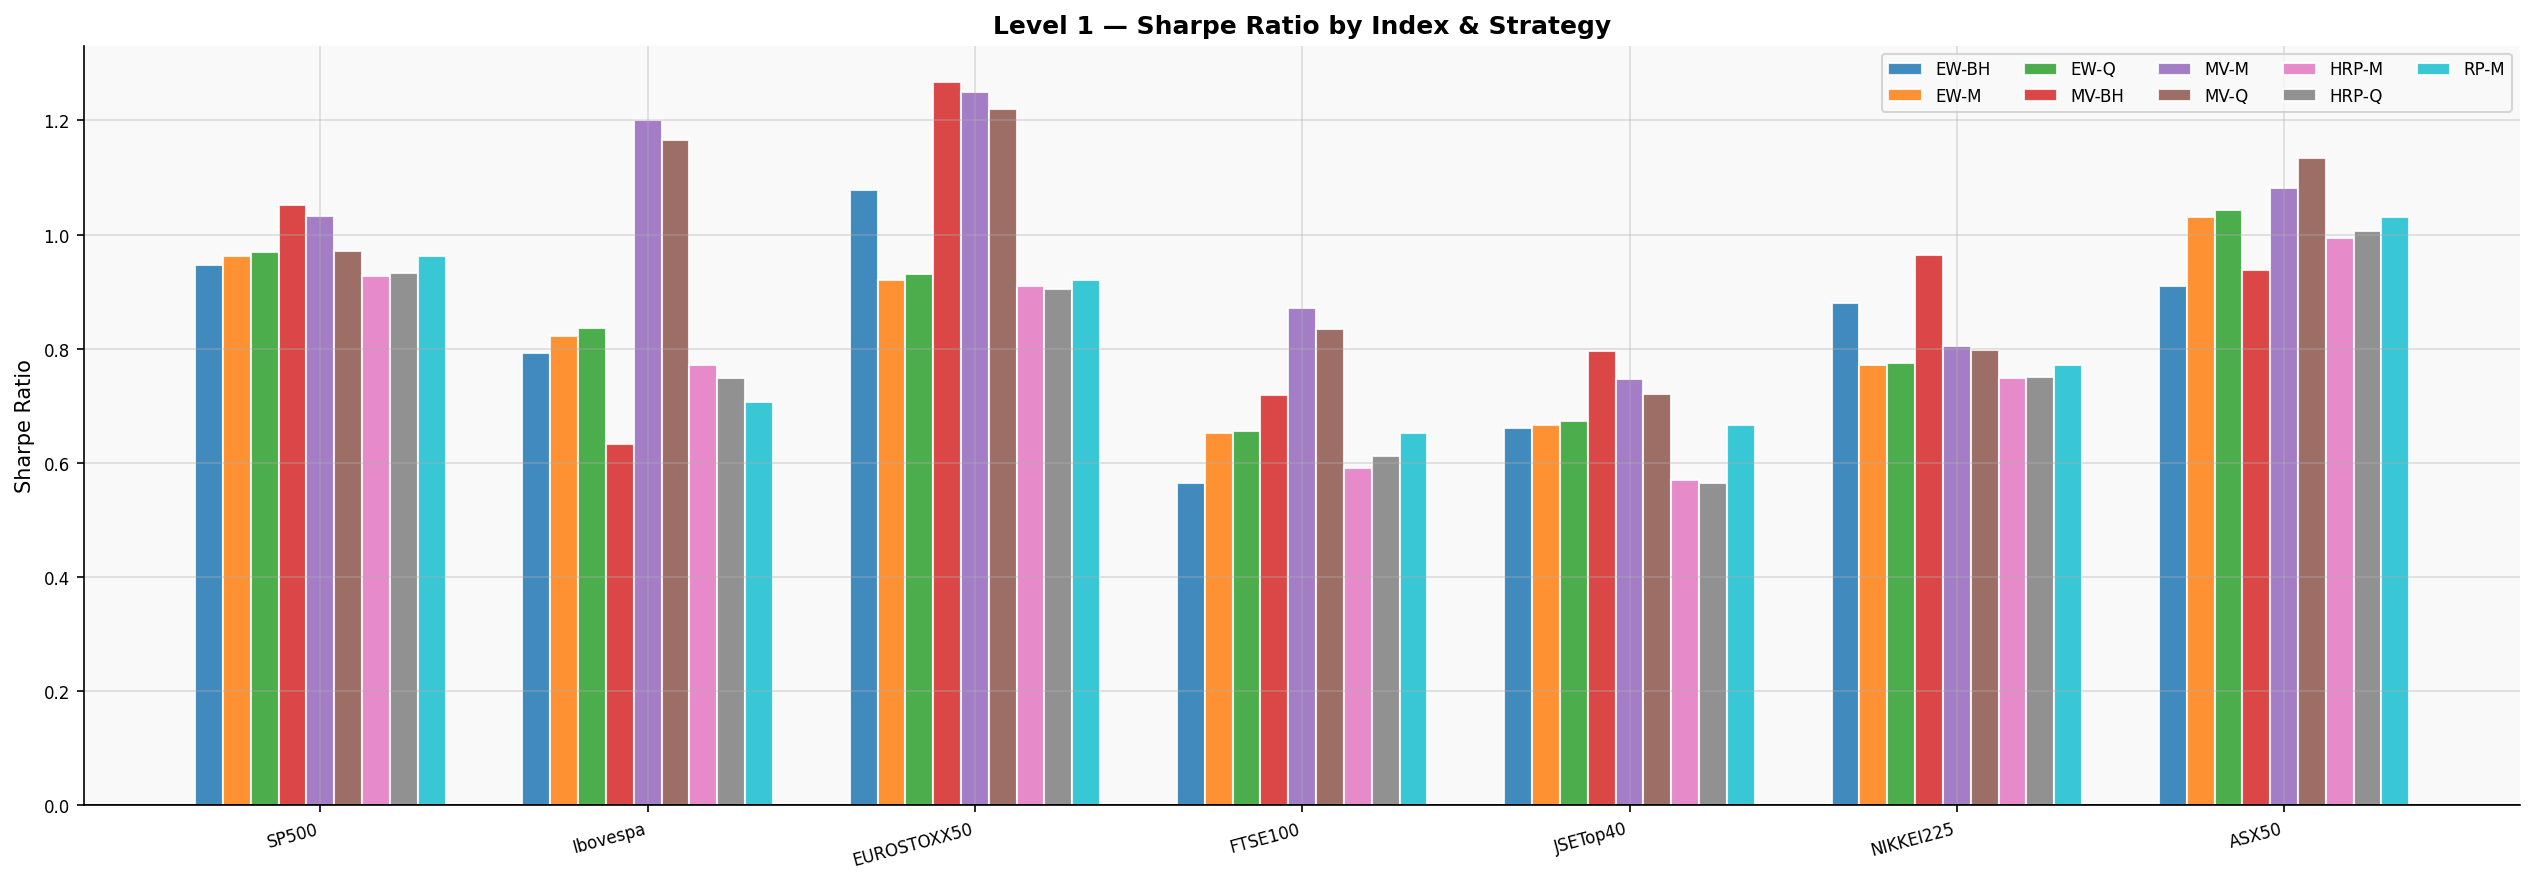

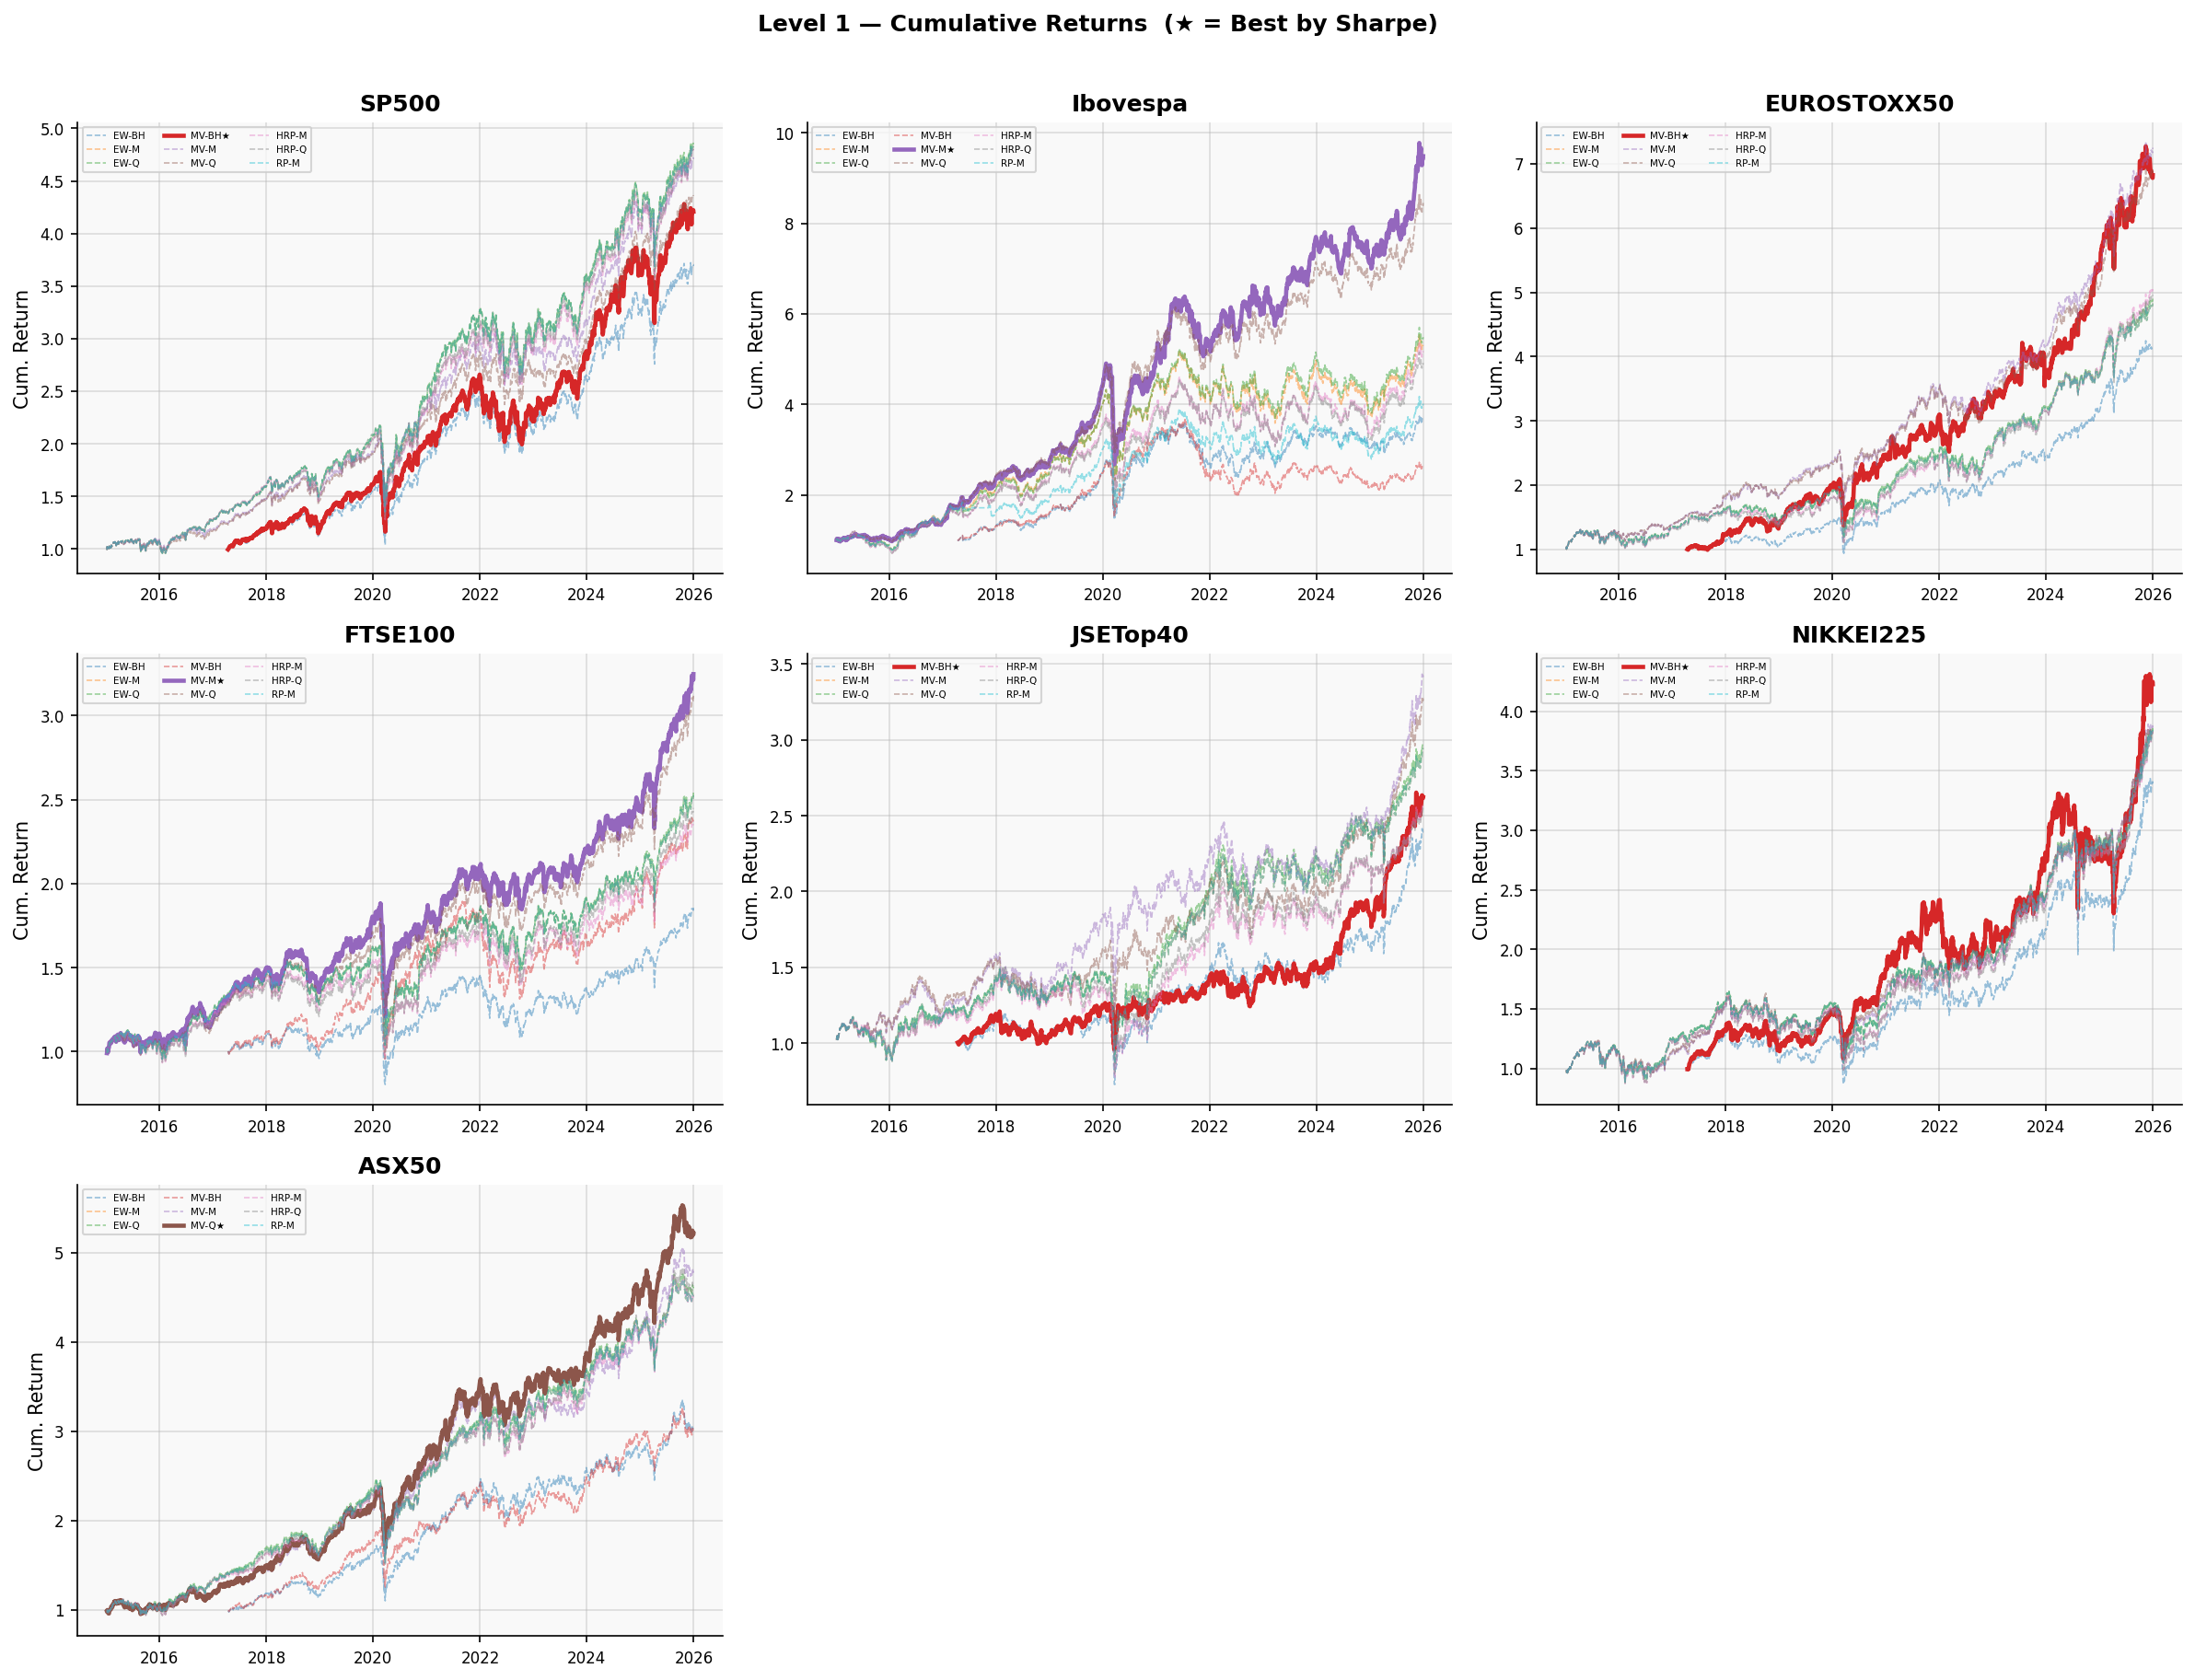

✅ Charts saved to outputs/


In [ ]:
G_COLORS = {
    "G1 Equal-Weight":"#2196F3", "G2 Mean-Variance":"#FF5722",
    "G3 Risk Parity":"#4CAF50",  "G4 HRP":"#9C27B0",
    "G4-VT HRP":"#00BCD4",       "G5 Macro-Enhanced":"#FF9800",
}
IDX_COLORS = ["#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd",
              "#8c564b","#e377c2","#7f7f7f","#bcbd22","#17becf",
              "#aec7e8","#ffbb78","#98df8a","#ff9896","#c5b0d5","#c49c94"]

def _savefig(fig, name):
    path=os.path.join(OUTPUT_DIR,name); fig.savefig(path,bbox_inches="tight")
    plt.close(fig); display(Image(path)); return path


def plot_level1_performance(level1_results):
    """Bar chart of Sharpe Ratio for all 9 strategies across all 7 indices."""
    indices=list(level1_results.keys()); strat_keys=list(STRATEGIES.keys())
    x=np.arange(len(indices)); bw=0.085
    palette=plt.cm.tab10(np.linspace(0,0.9,len(strat_keys)))
    fig,ax=plt.subplots(figsize=(17,6))
    for i,sk in enumerate(strat_keys):
        vals=[level1_results[idx].get(sk,{}).get("metrics",{}).get("Sharpe Ratio",np.nan)
              for idx in indices]
        ax.bar(x+(i-len(strat_keys)/2)*bw+bw/2, vals, bw,
               label=sk, color=palette[i], alpha=0.85, edgecolor="white")
    ax.axhline(0,color="black",lw=0.8)
    ax.set_xticks(x); ax.set_xticklabels(indices,rotation=15,ha="right")
    ax.set_ylabel("Sharpe Ratio")
    ax.set_title("Level 1 — Sharpe Ratio by Index & Strategy",fontweight="bold")
    ax.legend(ncol=5,loc="upper right"); plt.tight_layout()
    return _savefig(fig,"fig_l1_sharpe.png")


def plot_level1_cumulative(level1_results, best_level1):
    """One panel per index — cumulative returns for all strategies, best highlighted."""
    indices=list(level1_results.keys()); ncols=3
    palette=dict(zip(STRATEGIES.keys(),plt.cm.tab10(np.linspace(0,0.9,len(STRATEGIES)))))
    fig,axes=plt.subplots(int(np.ceil(len(indices)/ncols)),ncols,figsize=(16,4*3))
    axes=axes.flatten()
    for ai,idx_name in enumerate(indices):
        ax=axes[ai]; bk=best_level1[idx_name]["strategy"]
        for sk,data in level1_results[idx_name].items():
            cum=(1+data["returns"]).cumprod()
            ax.plot(cum.index,cum.values,
                    label=f"{sk}{'★' if sk==bk else ''}",color=palette[sk],
                    linewidth=2.2 if sk==bk else 0.8,
                    linestyle="-" if sk==bk else "--",
                    alpha=1.0 if sk==bk else 0.45)
        ax.set_title(idx_name,fontweight="bold"); ax.set_ylabel("Cum. Return")
        ax.legend(fontsize=5,ncol=3)
    for ai in range(len(indices),len(axes)): axes[ai].set_visible(False)
    fig.suptitle("Level 1 — Cumulative Returns  (★ = Best by Sharpe)",
                 fontweight="bold",y=1.01)
    plt.tight_layout()
    return _savefig(fig,"fig_l1_cumulative.png")


print("[Cell 9] Generating Level-1 charts...")
plot_level1_performance(level1_results)
plot_level1_cumulative(level1_results, best_level1)
print("✅ Charts saved to outputs/")


## Cell 10 · Convert Macro Data to Investable Return Streams

Converts the three macro asset classes into daily return series:

- **Bond yields** → approximate price return: `r_bond ≈ −7 × Δyield / 100`
- **FX rates & commodities** → standard log return: `r = ln(P_t / P_{t-1})`
- **VIX** → excluded (not investable)
- All series are **winsorised** at the 1st/99th percentile to remove yield-spike artifacts

**Expected output:** List of all available macro return series with their annualised volatility. Bond vols should be ~0.3-0.8%, FX ~5-10%, commodities ~20-70%.


In [ ]:
def build_macro_asset_returns(macro_df):
    """
    Convert macro price/yield series to daily investable return streams.
    Bond yields: r ≈ -BOND_DURATION × Δy / 100  (approximate price return)
    FX & commodities: standard log return
    VIX: excluded — it is not a tradeable return stream
    Returns are winsorised at 1st/99th percentile to remove data spikes.
    """
    if macro_df is None or macro_df.empty: return pd.DataFrame()
    result={}
    for col in macro_df.columns:
        if col=="VIX": continue
        s=macro_df[col].dropna()
        if len(s)<10: continue
        if col in BOND_COLS:
            dy=s.diff().dropna(); result[col]=-BOND_DURATION*dy/100.0
        elif col in FX_COLS+COMM_COLS:
            result[col]=np.log(s/s.shift(1)).dropna()
    if not result: return pd.DataFrame()
    df=(pd.DataFrame(result).replace([np.inf,-np.inf],np.nan).dropna(how="all"))
    for col in df.columns:
        lo,hi=df[col].quantile(0.01),df[col].quantile(0.99)
        df[col]=df[col].clip(lo,hi)
    return df


print("[Cell 10] Building macro investable return streams...")
macro_asset_rets = build_macro_asset_returns(macro_df)

if not macro_asset_rets.empty:
    avail=macro_asset_rets.columns.tolist()
    print(f"  Bonds      ({len([c for c in BOND_COLS if c in avail])}): {[c for c in BOND_COLS if c in avail]}")
    print(f"  FX         ({len([c for c in FX_COLS if c in avail])}): {[c for c in FX_COLS if c in avail]}")
    print(f"  Commodities({len([c for c in COMM_COLS if c in avail])}): {[c for c in COMM_COLS if c in avail]}")
    print("\n  Annualised volatility per series:")
    vol_summary = (macro_asset_rets.std()*np.sqrt(252)*100).round(2).to_frame("Ann. Vol %")
    display(vol_summary.T)
else:
    print("  ⚠️  No macro asset returns — Level-2 will use equity-only universe.")


[Cell 10] Building macro investable return streams...
  Bonds      (6): ['US_10Y', 'DE_10Y', 'UK_10Y', 'JP_10Y', 'AU_10Y', 'ZA_10Y']
  FX         (6): ['EURUSD', 'GBPUSD', 'JPYUSD', 'AUDUSD', 'BRLUSD', 'ZARUSD']
  Commodities(3): ['Gold', 'Oil', 'Bitcoin']

  Annualised volatility per series:


,AUDUSD,BRLUSD,Bitcoin,Oil,EURUSD,GBPUSD,Gold,JPYUSD,ZARUSD,US_10Y,DE_10Y,UK_10Y,JP_10Y,AU_10Y,ZA_10Y
Ann. Vol %,10.33,16.61,66.73,39.47,7.97,8.93,15.3,9.07,15.86,5.95,1.52,1.84,0.77,2.19,4.28


## Cell 11 · Build Level-2 Multi-Asset Universe

Combines the **7 best Level-1 equity return streams** with **15 macro return streams** into the full 22-asset investable universe.

All series are aligned to the common date intersection — any date where any series has a missing value is dropped.

**Expected output:** Shape of the combined DataFrame (rows × 22 columns) and the first few rows.


In [ ]:
def build_global_returns(best_level1, macro_asset_rets):
    """
    Stack 7 best Level-1 equity series + 15 macro return series.
    Result: 22-column DataFrame aligned to the common trading calendar.
    """
    equity_df=pd.DataFrame({idx:v["returns"] for idx,v in best_level1.items()}).dropna()
    if macro_asset_rets.empty:
        print("  WARNING: equity-only universe"); return equity_df
    combined=pd.concat([equity_df,macro_asset_rets],axis=1).dropna()
    n_eq,n_mc=equity_df.shape[1],macro_asset_rets.shape[1]
    print(f"  Multi-asset universe: {combined.shape[1]} assets ({n_eq} equity + {n_mc} macro)")
    print(f"  Date range: {combined.index[0].date()} → {combined.index[-1].date()}")
    print(f"  Trading days: {len(combined)}")
    return combined


print("[Cell 11] Building Level-2 multi-asset return universe...")
global_rets_df = build_global_returns(best_level1, macro_asset_rets)
macro_aligned  = (macro_df.reindex(global_rets_df.index).ffill()
                  if not macro_df.empty else pd.DataFrame(index=global_rets_df.index))

print("\n  Asset columns in the universe:")
print(f"  {global_rets_df.columns.tolist()}")
print("\n  Annualised return and vol of each series:")
summary = pd.DataFrame({
    "Ann. Return %": (global_rets_df.mean()*252*100).round(2),
    "Ann. Vol %":    (global_rets_df.std()*np.sqrt(252)*100).round(2),
})
display(summary)


[Cell 11] Building Level-2 multi-asset return universe...
  Multi-asset universe: 22 assets (7 equity + 15 macro)
  Date range: 2017-04-13 → 2025-12-30
  Trading days: 1906

  Asset columns in the universe:
  ['SP500', 'Ibovespa', 'EUROSTOXX50', 'FTSE100', 'JSETop40', 'NIKKEI225', 'ASX50', 'AUDUSD', 'BRLUSD', 'Bitcoin', 'Oil', 'EURUSD', 'GBPUSD', 'Gold', 'JPYUSD', 'ZARUSD', 'US_10Y', 'DE_10Y', 'UK_10Y', 'JP_10Y', 'AU_10Y', 'ZA_10Y']

  Annualised return and vol of each series:


,Ann. Return %,Ann. Vol %
SP500,21.30,19.93
Ibovespa,24.33,22.29
EUROSTOXX50,28.01,21.89
FTSE100,12.96,15.53
JSETop40,14.19,18.05
NIKKEI225,21.83,22.35
ASX50,20.15,16.65
AUDUSD,-1.37,10.03
BRLUSD,-6.39,15.82
Bitcoin,61.04,68.45


## Cell 12 · Build Level-2 Global Strategies (G1 – G5 + G4-VT)

Runs all six global strategies on the 22-asset universe:

| Strategy | Method | Lookback | Notes |
|---|---|---|---|
| G1 Equal-Weight | Static 1/N | — | Zero turnover baseline |
| G2 Mean-Variance | Ledoit-Wolf Max-Sharpe | 126d rolling | Monthly rebalance |
| G3 Risk Parity | Vol-norm. inverse-vol | 126d rolling | Monthly rebalance |
| G4 HRP | Two-tier HRP | 126d rolling | Monthly rebalance |
| G4-VT | G4 + 10% vol-target overlay | 63d vol window | Daily leverage [0.5×, 1.5×] |
| G5 Macro-Enhanced | Softmax macro signal | 20d signal | 40% blend, monthly |

**Expected output:** Vol-targeting report (raw G4 vol vs G4-VT vol), confirming the overlay works correctly.


In [ ]:
# ── G1: Equal-Weight (static, zero turnover) ─────────────────────────────────
def g1_equal_weight(global_rets):
    """1/N across all 22 assets. No rebalancing, no estimation."""
    n=global_rets.shape[1]; w=equal_weights(n)
    wdf=pd.DataFrame(np.tile(w,(len(global_rets),1)),
                     index=global_rets.index,columns=global_rets.columns)
    return (global_rets*w).sum(axis=1), wdf, compute_turnover(wdf)


# ── G2: Mean-Variance (Ledoit-Wolf, 126d rolling) ────────────────────────────
def g2_mean_variance(global_rets, rolling_window=126, rebal_freq="BMS"):
    """
    Max-Sharpe MV with Ledoit-Wolf shrinkage.
    126-day window (6 months) keeps covariance estimates stable enough to
    avoid excessive monthly turnover.
    """
    port_ret,wdf=simulate_portfolio(global_rets,markowitz_weights,
                                    rebal_freq=rebal_freq,lookback=rolling_window)
    return port_ret,wdf,compute_turnover(wdf)


# ── G3: Vol-Normalised Risk Parity (126d rolling) ────────────────────────────
def g3_risk_parity(global_rets, rolling_window=126, rebal_freq="BMS"):
    """
    Inverse-vol RP with cross-asset vol normalisation.
    Without normalisation, bonds get 50× the weight of equities in raw terms.
    """
    port_ret,wdf=simulate_portfolio(global_rets,risk_parity_weights,
                                    rebal_freq=rebal_freq,lookback=rolling_window)
    return port_ret,wdf,compute_turnover(wdf)


# ── G4: Two-Tier HRP (126d rolling) ─────────────────────────────────────────
def g4_hrp(global_rets, rolling_window=126, rebal_freq="BMS"):
    """
    Hierarchical Risk Parity run at the asset-class level first, then within
    each class. Prevents the equity cluster from dominating the allocation.
    """
    port_ret,wdf=simulate_portfolio(global_rets,hrp_weights,
                                    rebal_freq=rebal_freq,lookback=rolling_window)
    return port_ret,wdf,compute_turnover(wdf)


# ── Vol-Targeting Overlay ─────────────────────────────────────────────────────
def apply_vol_target(port_ret, weights_df, target_vol=0.10,
                     estimation_window=63, leverage_min=0.50, leverage_max=1.50,
                     periods=252):
    """
    Daily leverage overlay: L_t = target_vol / σ̂_{t-1}, clipped to [0.5×, 1.5×].
    σ̂ is the 63-day (3-month) trailing standard deviation of portfolio returns.
    No look-ahead: leverage at t uses data through t-1 only.
    """
    target_daily=target_vol/np.sqrt(periods)
    leverages=pd.Series(index=port_ret.index, dtype=float)
    for i,date in enumerate(port_ret.index):
        if i<10: leverages.iloc[i]=1.0
        else:
            window=port_ret.iloc[max(0,i-estimation_window):i]
            rv=window.std()
            leverages.iloc[i]=float(np.clip(target_daily/rv,leverage_min,leverage_max)) if rv>1e-10 else 1.0
    vt_ret=port_ret*leverages;  vt_weights=weights_df.multiply(leverages,axis=0)
    return vt_ret, vt_weights, leverages


def g4_hrp_vt(global_rets, rolling_window=126, rebal_freq="BMS", target_vol=0.10):
    """G4 HRP followed by a 10% vol-targeting overlay applied post-allocation."""
    raw_ret,raw_wdf=simulate_portfolio(global_rets,hrp_weights,
                                       rebal_freq=rebal_freq,lookback=rolling_window)
    vt_ret,vt_wdf,leverages=apply_vol_target(raw_ret,raw_wdf,target_vol=target_vol)
    return vt_ret,vt_wdf,compute_turnover(vt_wdf),leverages


# ── G5: Macro-Enhanced ───────────────────────────────────────────────────────
def _macro_signal(macro_df, global_rets, date):
    """
    Multi-factor softmax signal for all 22 assets.
    Score = 0.40×Momentum + 0.20×VIX + 0.20×Yield-signal + 0.20×FX-signal
    Scores are Z-score standardised before softmax (temperature 0.8)
    so that bond momentum (~0.001) is not swamped by equity momentum (~0.05).
    """
    ALPHA,BETA,GAMMA,DELTA,TEMP,LB=0.40,0.20,0.20,0.20,0.8,20
    all_assets=global_rets.columns.tolist(); n=len(all_assets)
    past=global_rets.loc[:date].tail(LB+1)
    if len(past)<LB: return equal_weights(n)
    past_norm=past.copy()
    for col in past_norm.columns:
        s=past_norm[col].std()
        if s>1e-10: past_norm[col]=(past_norm[col]-past_norm[col].mean())/s
    momentum=past_norm.iloc[-1].values-past_norm.iloc[0].values
    vix_signal=0.0
    if "VIX" in macro_df.columns:
        vix_h=macro_df["VIX"].loc[:date].tail(LB*6)
        if len(vix_h)>=2: vix_signal=-(vix_h.iloc[-1]/vix_h.mean()-1)
    yield_eq_map={"SP500":"US_10Y","Ibovespa":"BR_10Y","EUROSTOXX50":"DE_10Y",
                  "FTSE100":"UK_10Y","JSETop40":"ZA_10Y","NIKKEI225":"JP_10Y","ASX50":"AU_10Y"}
    fx_eq_map={"SP500":None,"Ibovespa":"BRLUSD","EUROSTOXX50":"EURUSD",
               "FTSE100":"GBPUSD","JSETop40":"ZARUSD","NIKKEI225":"JPYUSD","ASX50":"AUDUSD"}
    rate_signals,fx_signals=np.zeros(n),np.zeros(n)
    for i,asset in enumerate(all_assets):
        if asset in EQUITY_INDICES:
            ycol=yield_eq_map.get(asset)
            if ycol and ycol in macro_df.columns:
                yld=macro_df[ycol].loc[:date].tail(LB+1)
                if len(yld)>=2: rate_signals[i]=-(yld.iloc[-1]-yld.iloc[0])
            fcol=fx_eq_map.get(asset)
            if fcol and fcol in macro_df.columns:
                fx=macro_df[fcol].loc[:date].tail(LB+1)
                if len(fx)>=2: fx_signals[i]=np.log(fx.iloc[-1]/fx.iloc[0])
        elif asset in BOND_COLS:
            rate_signals[i]=momentum[i];  fx_signals[i]=vix_signal
        elif asset in FX_COLS:  fx_signals[i]=momentum[i]
        elif asset in COMM_COLS:
            fx_signals[i]={"Gold":1.0,"Oil":-0.5,"Bitcoin":0.3}.get(asset,0.0)*vix_signal
    raw=(ALPHA*momentum+BETA*vix_signal+GAMMA*rate_signals+DELTA*fx_signals)
    sc_std=raw.std()
    if sc_std>1e-10: raw=(raw-raw.mean())/sc_std
    raw/=TEMP;  raw-=raw.max();  exp_s=np.exp(raw);  return exp_s/exp_s.sum()


def g5_macro_enhanced(global_rets, macro_df, rebal_freq="BMS"):
    """
    Monthly macro-signal re-evaluation across all 22 assets.
    New weights are blended 40% new / 60% previous to limit turnover.
    """
    rebal_dates=get_rebalance_dates(global_rets.index,rebal_freq)
    n=global_rets.shape[1]; current_w=equal_weights(n)
    w_dict,r_dict={},{}
    BLEND=0.4
    for date in global_rets.index:
        if date in rebal_dates:
            try:
                new_w=_macro_signal(macro_df,global_rets,date)
                current_w=BLEND*new_w+(1-BLEND)*current_w
                current_w/=current_w.sum()
            except: pass
        w_dict[date]=current_w.copy()
        r_dict[date]=float(global_rets.loc[date].values@current_w)
    port_ret=pd.Series(r_dict); wdf=pd.DataFrame(w_dict).T
    wdf.columns=global_rets.columns
    return port_ret,wdf,compute_turnover(wdf)


# ── Run all six strategies ────────────────────────────────────────────────────
print("[Cell 12] Building Level-2 global portfolios...")
print("  G1: Equal-Weight...")
g1_ret,g1_w,g1_to   = g1_equal_weight(global_rets_df)
print("  G2: Mean-Variance (Ledoit-Wolf, 126d)...")
g2_ret,g2_w,g2_to   = g2_mean_variance(global_rets_df)
print("  G3: Vol-Norm. Risk Parity (126d)...")
g3_ret,g3_w,g3_to   = g3_risk_parity(global_rets_df)
print("  G4: Two-Tier HRP (126d)...")
g4_ret,g4_w,g4_to   = g4_hrp(global_rets_df)
print("  G4-VT: HRP + 10% vol-targeting overlay...")
g4vt_ret,g4vt_w,g4vt_to,g4vt_lev = g4_hrp_vt(global_rets_df, target_vol=0.10)
print("  G5: Macro-Enhanced (40% blend, monthly)...")
g5_ret,g5_w,g5_to   = g5_macro_enhanced(global_rets_df, macro_aligned)

G_COLORS["G4-VT HRP"]="#00BCD4"

g4_vol   = annualise_vol(g4_ret)*100
g4vt_vol = annualise_vol(g4vt_ret)*100
print(f"\n  Vol-targeting result:")
print(f"    G4  raw vol : {g4_vol:.2f}%")
print(f"    G4-VT   vol : {g4vt_vol:.2f}%  (target = 10.0%,  avg leverage = {g4vt_lev.mean():.3f}×)")
print("\n✅ All Level-2 strategies built.")


[Cell 12] Building Level-2 global portfolios...
  G1: Equal-Weight...
  G2: Mean-Variance (Ledoit-Wolf, 126d)...
  G3: Vol-Norm. Risk Parity (126d)...
  G4: Two-Tier HRP (126d)...
  G4-VT: HRP + 10% vol-targeting overlay...
  G5: Macro-Enhanced (40% blend, monthly)...

  Vol-targeting result:
    G4  raw vol : 12.06%
    G4-VT   vol : 10.77%  (target = 10.0%,  avg leverage = 1.020×)

✅ All Level-2 strategies built.


## Cell 13 · Level-2 Performance Table

Computes all metrics for the six global strategies. G1 Equal-Weight is used as the benchmark for **Beta**, **Alpha**, and **Information Ratio**.

TC net returns are shown at 0% / 0.5% / 1% / 2% so you can assess viability under different implementation cost assumptions.

**Expected output:** Styled performance table (6 rows × 19 columns) and CSV saved.


In [ ]:
def build_global_summary(global_metrics):
    df=pd.DataFrame(global_metrics)
    front=["Strategy","Ann. Return (%)","Ann. Volatility (%)","Sharpe Ratio",
           "Sortino Ratio","Max Drawdown (%)","Calmar Ratio","VaR 95% (daily %)",
           "CVaR 95% (daily %)","Hit Rate (%)","Omega Ratio","Beta","Alpha (ann. %)",
           "Information Ratio","Mean Turnover","Net Ret TC=0.0% (%)","Net Ret TC=0.5% (%)",
           "Net Ret TC=1.0% (%)","Net Ret TC=2.0% (%)"]
    return df[[c for c in front if c in df.columns]].reset_index(drop=True)


# Build the global strategy registry
global_port_rets = {
    "G1 Equal-Weight":g1_ret, "G2 Mean-Variance":g2_ret,
    "G3 Risk Parity":g3_ret,  "G4 HRP":g4_ret,
    "G4-VT HRP":g4vt_ret,     "G5 Macro-Enhanced":g5_ret,
}
global_weights = {
    "G1 Equal-Weight":g1_w,  "G2 Mean-Variance":g2_w,
    "G3 Risk Parity":g3_w,   "G4 HRP":g4_w,
    "G4-VT HRP":g4vt_w,      "G5 Macro-Enhanced":g5_w,
}
global_turnovers = {
    "G1 Equal-Weight":g1_to, "G2 Mean-Variance":g2_to,
    "G3 Risk Parity":g3_to,  "G4 HRP":g4_to,
    "G4-VT HRP":g4vt_to,     "G5 Macro-Enhanced":g5_to,
}
benchmark_ret = g1_ret   # G1 EW is the benchmark for Beta/Alpha/IR

global_metrics = []
for label,ret in global_port_rets.items():
    tv=global_turnovers[label]
    m=performance_table(ret,label=label,turnover=tv,
                         benchmark=benchmark_ret,cost_rates=[0.0,0.005,0.01,0.02])
    global_metrics.append(m)

g_summary = build_global_summary(global_metrics)
g_summary.to_csv(f"{OUTPUT_DIR}/table_global_performance.csv", index=False)

fmt={c:"{:.2f}" for c in g_summary.columns if "%" in c}
fmt.update({"Sharpe Ratio":"{:.3f}","Sortino Ratio":"{:.3f}","Calmar Ratio":"{:.3f}",
            "Omega Ratio":"{:.3f}","Beta":"{:.3f}","Information Ratio":"{:.3f}",
            "Mean Turnover":"{:.4f}"})
display(g_summary.style
    .format(fmt, na_rep="—")
    .background_gradient(subset=["Sharpe Ratio"], cmap="RdYlGn")
    .background_gradient(subset=["Max Drawdown (%)"], cmap="RdYlGn_r")
    .set_caption("Level 2: Global portfolio strategies — full metrics"))
print(f"\n✅ Saved → {OUTPUT_DIR}/table_global_performance.csv")


,Strategy,Ann. Return (%),Ann. Volatility (%),Sharpe Ratio,Sortino Ratio,Max Drawdown (%),Calmar Ratio,VaR 95% (daily %),CVaR 95% (daily %),Hit Rate (%),Omega Ratio,Beta,Alpha (ann. %),Information Ratio,Mean Turnover,Net Ret TC=0.0% (%),Net Ret TC=0.5% (%),Net Ret TC=1.0% (%),Net Ret TC=2.0% (%)
0,G1 Equal-Weight,9.40,6.94,1.355,1.622,-15.21,0.618,-0.59,-1.05,56.45,1.277,1.000,0.00,—,0.0000,9.40,9.40,9.40,9.40
1,G2 Mean-Variance,10.08,6.90,1.460,1.924,-9.95,1.014,-0.61,-1.05,55.98,1.301,0.761,2.93,0.144,0.0311,10.08,6.17,2.26,-5.57
2,G3 Risk Parity,11.69,6.90,1.695,2.111,-14.26,0.820,-0.60,-1.01,57.35,1.351,0.990,2.38,3.692,0.0085,11.69,10.61,9.54,7.39
3,G4 HRP,16.14,12.06,1.339,1.771,-26.10,0.618,-1.16,-1.80,55.88,1.276,1.479,2.24,0.942,0.0243,16.14,13.07,10.01,3.88
4,G4-VT HRP,13.58,10.77,1.260,1.704,-19.79,0.686,-1.03,-1.58,55.88,1.247,1.314,1.22,0.681,0.0309,13.58,9.68,5.78,-2.02
5,G5 Macro-Enhanced,8.73,5.72,1.525,1.750,-13.56,0.644,-0.51,-0.88,57.66,1.328,0.766,1.53,-0.250,0.0211,8.73,6.07,3.41,-1.90



✅ Saved → outputs/table_global_performance.csv


## Cell 14 · Regime Analysis

Splits the sample into three market environments:

| Period | Dates | Character |
|---|---|---|
| Pre-COVID | Jan 2015 – Dec 2019 | Low-vol bull market, accommodative policy |
| COVID Shock | Jan 2020 – Dec 2020 | Pandemic drawdown + V-shaped recovery |
| Recovery | Jan 2021 – Dec 2025 | Inflation, rate hikes, AI equity rally |

**Expected output:** Styled regime table and bar chart comparing Sharpe Ratio and return by period across all six strategies.


[Cell 14] Running regime analysis...


,Strategy,Pre-COVID (2015-2019) Ret%,Pre-COVID (2015-2019) Sharpe,Pre-COVID (2015-2019) MDD%,COVID Shock (2020) Ret%,COVID Shock (2020) Sharpe,COVID Shock (2020) MDD%,Recovery (2021-2025) Ret%,Recovery (2021-2025) Sharpe,Recovery (2021-2025) MDD%
0,G1 Equal-Weight,10.58,1.924,-10.61,16.95,1.468,-15.21,7.24,1.125,-11.77
1,G2 Mean-Variance,11.13,2.464,-5.85,16.58,1.859,-9.95,8.20,1.089,-9.48
2,G3 Risk Parity,13.25,2.343,-8.72,21.16,1.905,-14.26,8.93,1.388,-11.03
3,G4 HRP,16.98,1.329,-23.68,25.23,1.516,-18.71,13.86,1.325,-16.59
4,G4-VT HRP,15.88,1.497,-19.79,7.25,0.548,-17.84,13.53,1.311,-15.61
5,G5 Macro-Enhanced,8.33,1.961,-8.83,9.35,1.028,-13.56,8.83,1.578,-10.51


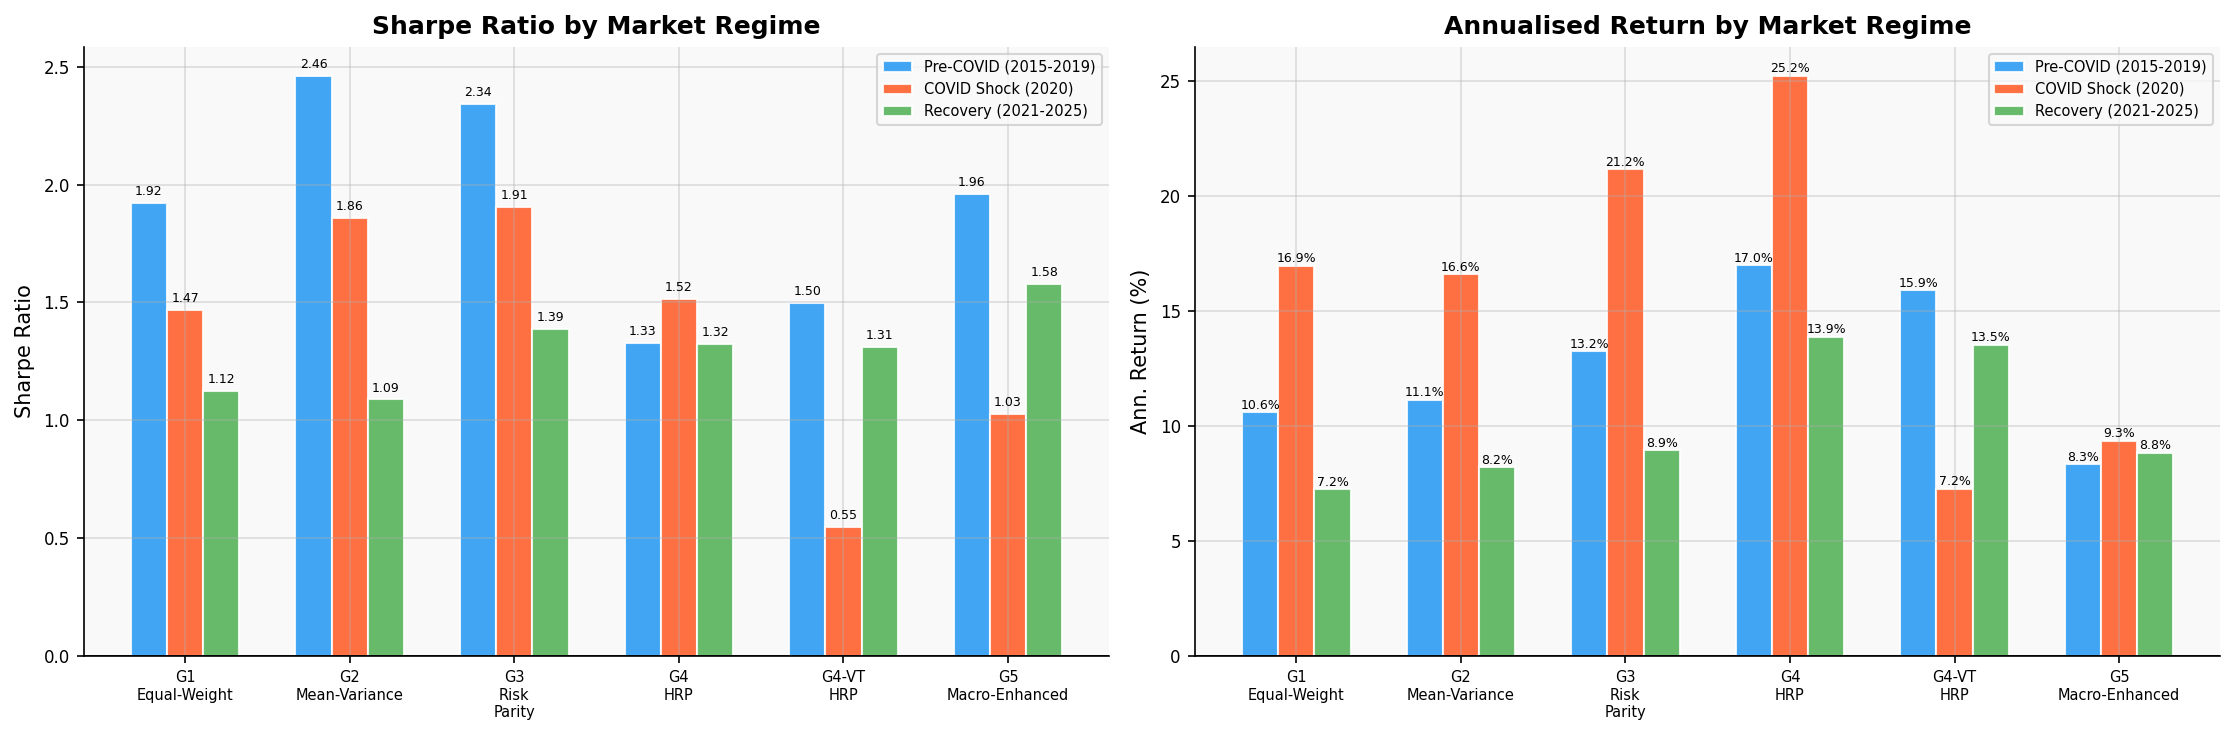

✅ Saved → outputs/table_regime_analysis.csv


In [ ]:
REGIMES = {
    "Pre-COVID (2015-2019)":  ("2015-01-01","2019-12-31"),
    "COVID Shock (2020)":     ("2020-01-01","2020-12-31"),
    "Recovery (2021-2025)":   ("2021-01-01","2025-12-31"),
}


def build_regime_table(global_port_rets, benchmark_ret):
    """Compute Sharpe, return, and MDD for each strategy × regime combination."""
    rows=[]
    for label,ret in global_port_rets.items():
        row={"Strategy":label}
        for rname,(start,end) in REGIMES.items():
            sub=ret.loc[start:end]
            if len(sub)<20:
                row[f"{rname} Ret%"]=row[f"{rname} Sharpe"]=row[f"{rname} MDD%"]=np.nan
            else:
                row[f"{rname} Ret%"]  =round(annualise_return(sub)*100,2)
                row[f"{rname} Sharpe"]=round(sharpe_ratio(sub),3)
                row[f"{rname} MDD%"]  =round(max_drawdown(sub)*100,2)
        rows.append(row)
    return pd.DataFrame(rows)


def plot_regime_bars(regime_df):
    """Side-by-side grouped bar chart: Sharpe (left) and return (right) by regime."""
    strategies=regime_df["Strategy"].tolist()
    regime_keys=list(REGIMES.keys()); x=np.arange(len(strategies)); bw=0.22
    palette=["#2196F3","#FF5722","#4CAF50"]
    fig,axes=plt.subplots(1,2,figsize=(15,5))
    for ax_i,metric in enumerate(["Sharpe","Ret%"]):
        ax=axes[ax_i]
        for i,rk in enumerate(regime_keys):
            col=f"{rk} {metric}"
            vals=regime_df[col].tolist(); offset=(i-len(regime_keys)/2)*bw+bw/2
            bars=ax.bar(x+offset,vals,bw,label=rk,color=palette[i],alpha=0.85,edgecolor="white")
            for bar,val in zip(bars,vals):
                if not np.isnan(val):
                    ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.02,
                            f"{val:.2f}" if metric=="Sharpe" else f"{val:.1f}%",
                            ha="center",va="bottom",fontsize=6)
        ax.axhline(0,color="black",lw=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels([s.replace(" ", "\n") for s in strategies], fontsize=7)
        ax.set_ylabel("Sharpe Ratio" if metric=="Sharpe" else "Ann. Return (%)")
        ax.set_title(f"{'Sharpe Ratio' if metric=='Sharpe' else 'Annualised Return'} by Market Regime",fontweight="bold")
        ax.legend(fontsize=7)
    plt.tight_layout()
    return _savefig(fig,"fig_regime_analysis.png")


print("[Cell 14] Running regime analysis...")
regime_df = build_regime_table(global_port_rets, benchmark_ret)
regime_df.to_csv(f"{OUTPUT_DIR}/table_regime_analysis.csv", index=False)

sharpe_cols=[c for c in regime_df.columns if "Sharpe" in c]
mdd_cols   =[c for c in regime_df.columns if "MDD%" in c]
fmt_r={c:"{:.3f}" for c in sharpe_cols}
fmt_r.update({c:"{:.2f}" for c in [c for c in regime_df.columns if c!="Strategy" and c not in sharpe_cols]})
display(regime_df.style
    .format(fmt_r,na_rep="—")
    .background_gradient(subset=sharpe_cols,cmap="RdYlGn")
    .background_gradient(subset=mdd_cols,cmap="RdYlGn_r")
    .set_caption("Regime Analysis: Performance by Market Period"))

plot_regime_bars(regime_df)
print(f"✅ Saved → {OUTPUT_DIR}/table_regime_analysis.csv")


## Cell 15 · Core Global Portfolio Charts

Four charts that give the primary read on Level-2 strategy performance:

1. **Cumulative returns** — who grew your money most over 11 years
2. **Drawdown chart** — how deep each strategy fell and for how long
3. **Rolling Sharpe** (126-day window) — risk-adjusted performance through time
4. **Rolling Volatility** (63-day window) — confirms the vol-targeting overlay works

**Expected output:** All four charts displayed inline and saved to `outputs/`.


[Cell 15] Generating core performance charts...


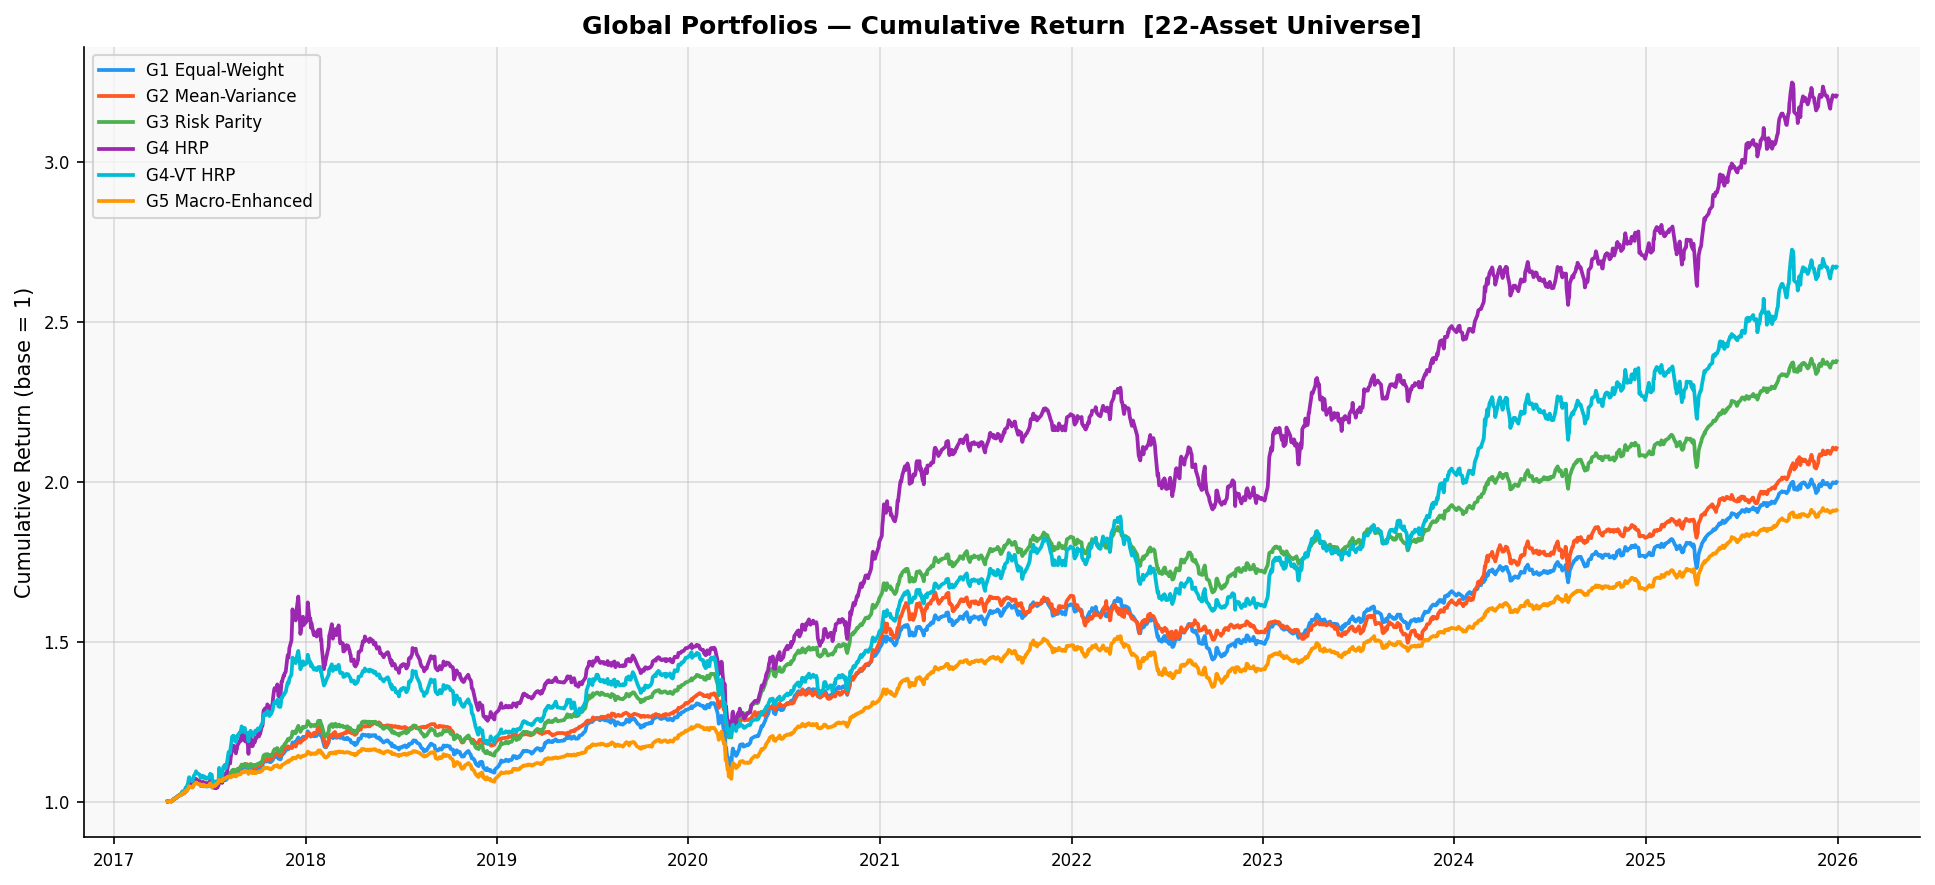

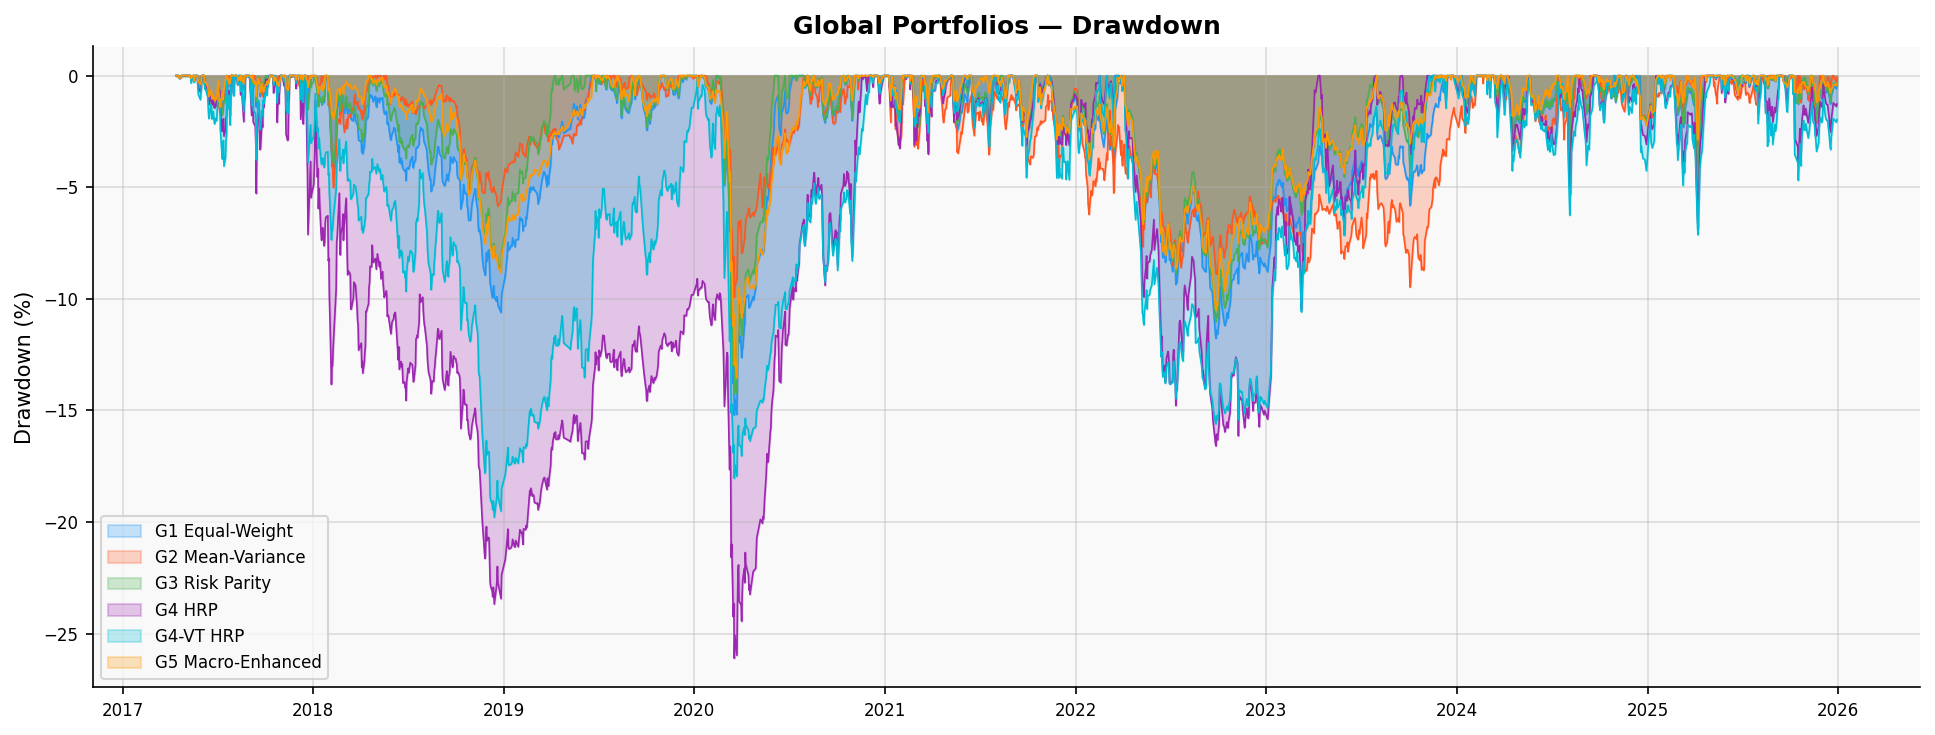

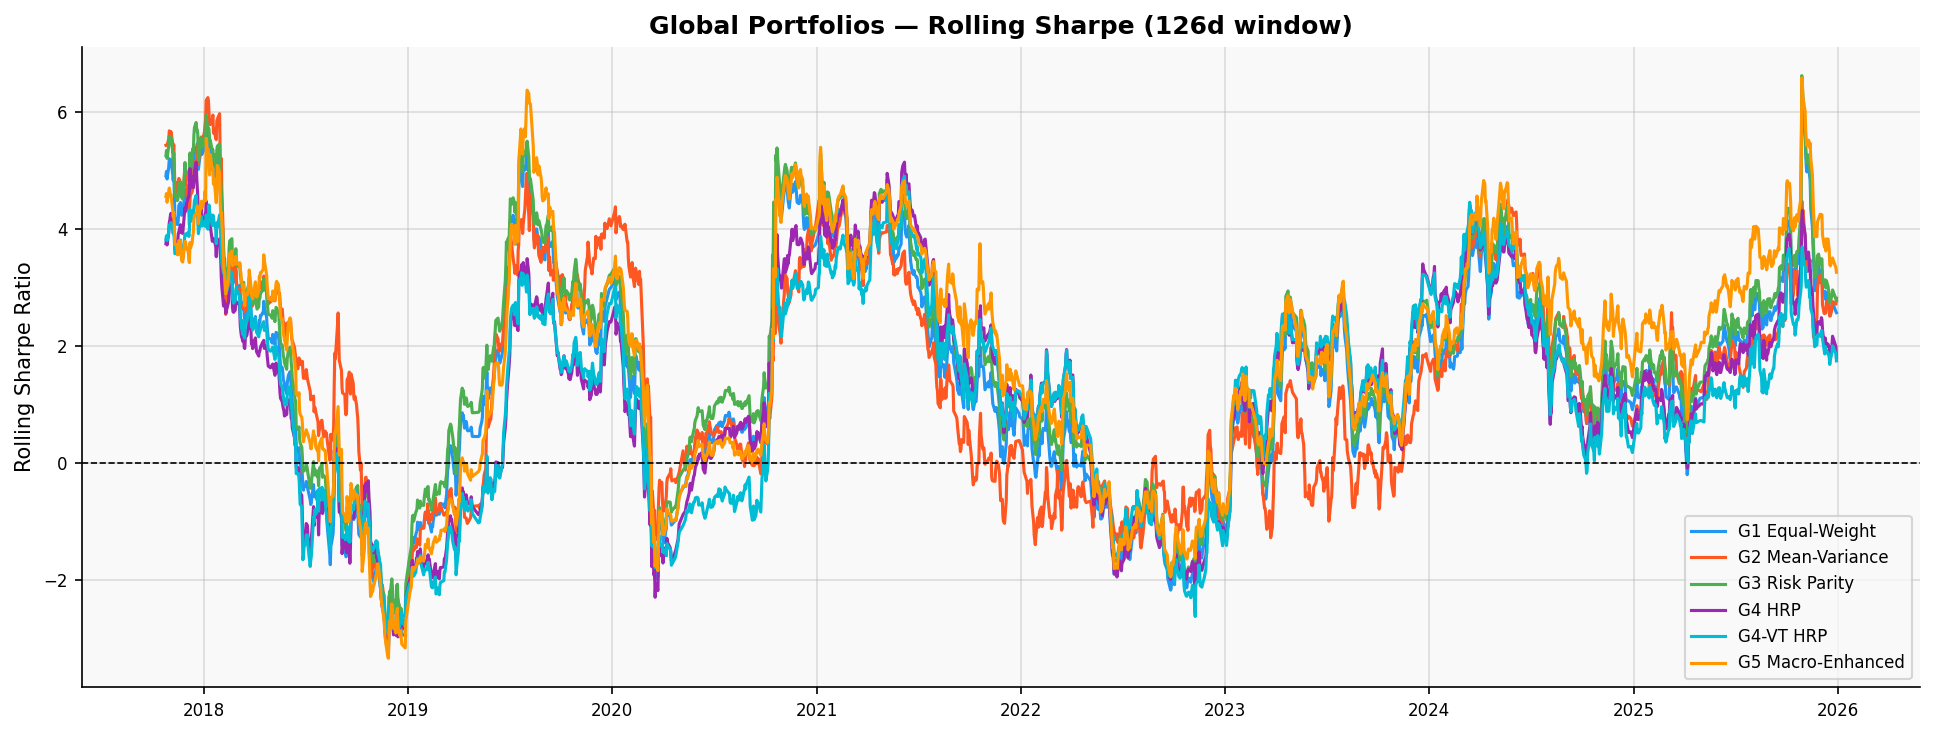

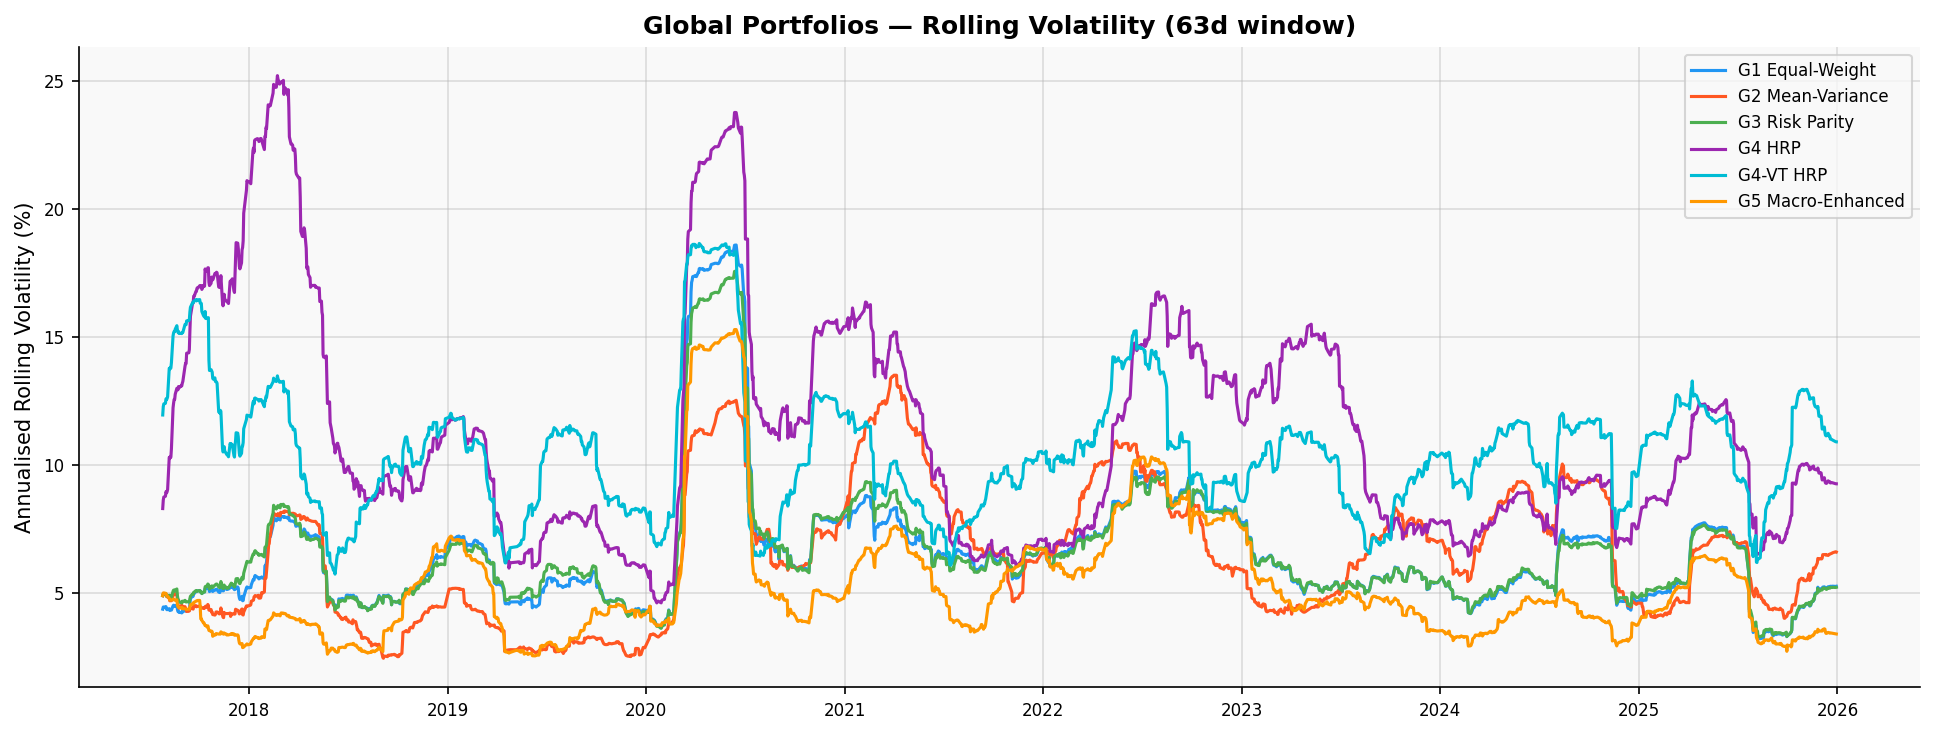

✅ Four core charts saved.


In [ ]:
def rolling_sharpe(ret, window=126, periods=252):
    return ret.rolling(window).mean()*periods/(ret.rolling(window).std()*np.sqrt(periods))


def plot_cumulative_returns(global_port_rets):
    """Cumulative wealth index for all six strategies (base = 1)."""
    fig,ax=plt.subplots(figsize=(13,6))
    for label,ret in global_port_rets.items():
        cum=(1+ret).cumprod()
        ax.plot(cum.index,cum.values,label=label,color=G_COLORS.get(label,"grey"),lw=1.8)
    ax.set_ylabel("Cumulative Return (base = 1)")
    ax.set_title("Global Portfolios — Cumulative Return  [22-Asset Universe]",fontweight="bold")
    ax.legend(); plt.tight_layout()
    return _savefig(fig,"fig_global_cumulative.png")


def plot_drawdowns(global_port_rets):
    """Underwater equity curve for all strategies — shows depth and duration of drawdowns."""
    fig,ax=plt.subplots(figsize=(13,5))
    for label,ret in global_port_rets.items():
        dd=drawdown_series(ret)*100
        ax.fill_between(dd.index,dd.values,0,alpha=0.25,color=G_COLORS.get(label,"grey"),label=label)
        ax.plot(dd.index,dd.values,color=G_COLORS.get(label,"grey"),lw=0.8)
    ax.set_ylabel("Drawdown (%)"); ax.set_title("Global Portfolios — Drawdown",fontweight="bold")
    ax.legend(); plt.tight_layout()
    return _savefig(fig,"fig_global_drawdowns.png")


def plot_rolling_sharpe_chart(global_port_rets, window=126):
    """Rolling 126-day (6-month) Sharpe Ratio — tracks regime-by-regime performance."""
    fig,ax=plt.subplots(figsize=(13,5))
    for label,ret in global_port_rets.items():
        rs=rolling_sharpe(ret,window)
        ax.plot(rs.index,rs.values,label=label,color=G_COLORS.get(label,"grey"),lw=1.5)
    ax.axhline(0,color="black",lw=0.8,ls="--")
    ax.set_ylabel("Rolling Sharpe Ratio")
    ax.set_title(f"Global Portfolios — Rolling Sharpe ({window}d window)",fontweight="bold")
    ax.legend(); plt.tight_layout()
    return _savefig(fig,"fig_global_rolling_sharpe.png")


def plot_rolling_vol(global_port_rets, window=63):
    """Rolling 63-day (3-month) annualised volatility — confirms vol-targeting overlay."""
    fig,ax=plt.subplots(figsize=(13,5))
    for label,ret in global_port_rets.items():
        rv=ret.rolling(window).std()*np.sqrt(252)*100
        ax.plot(rv.index,rv.values,label=label,color=G_COLORS.get(label,"grey"),lw=1.5)
    ax.set_ylabel("Annualised Rolling Volatility (%)")
    ax.set_title(f"Global Portfolios — Rolling Volatility ({window}d window)",fontweight="bold")
    ax.legend(); plt.tight_layout()
    return _savefig(fig,"fig_rolling_vol.png")


print("[Cell 15] Generating core performance charts...")
plot_cumulative_returns(global_port_rets)
plot_drawdowns(global_port_rets)
plot_rolling_sharpe_chart(global_port_rets)
plot_rolling_vol(global_port_rets)
print("✅ Four core charts saved.")


## Cell 16 · Transaction Cost Robustness & Efficient Frontier

Two charts for evaluating practical implementability:

1. **TC robustness bar chart** — net annualised return at four cost levels (0%, 0.5%, 1%, 2%). Bars that shrink fast have high turnover; G3 Risk Parity barely changes.
2. **Efficient frontier scatter** — each strategy plotted as (vol, return) with iso-Sharpe lines at 1.0, 1.5, 2.0. Bubble size is proportional to mean daily turnover.

**Expected output:** Both charts inline. Note how G3 RP and G5 Macro sit near the SR=1.5 line at low vol, while G4 HRP has the highest return but farthest right (highest vol).


[Cell 16] TC robustness and efficient frontier charts...


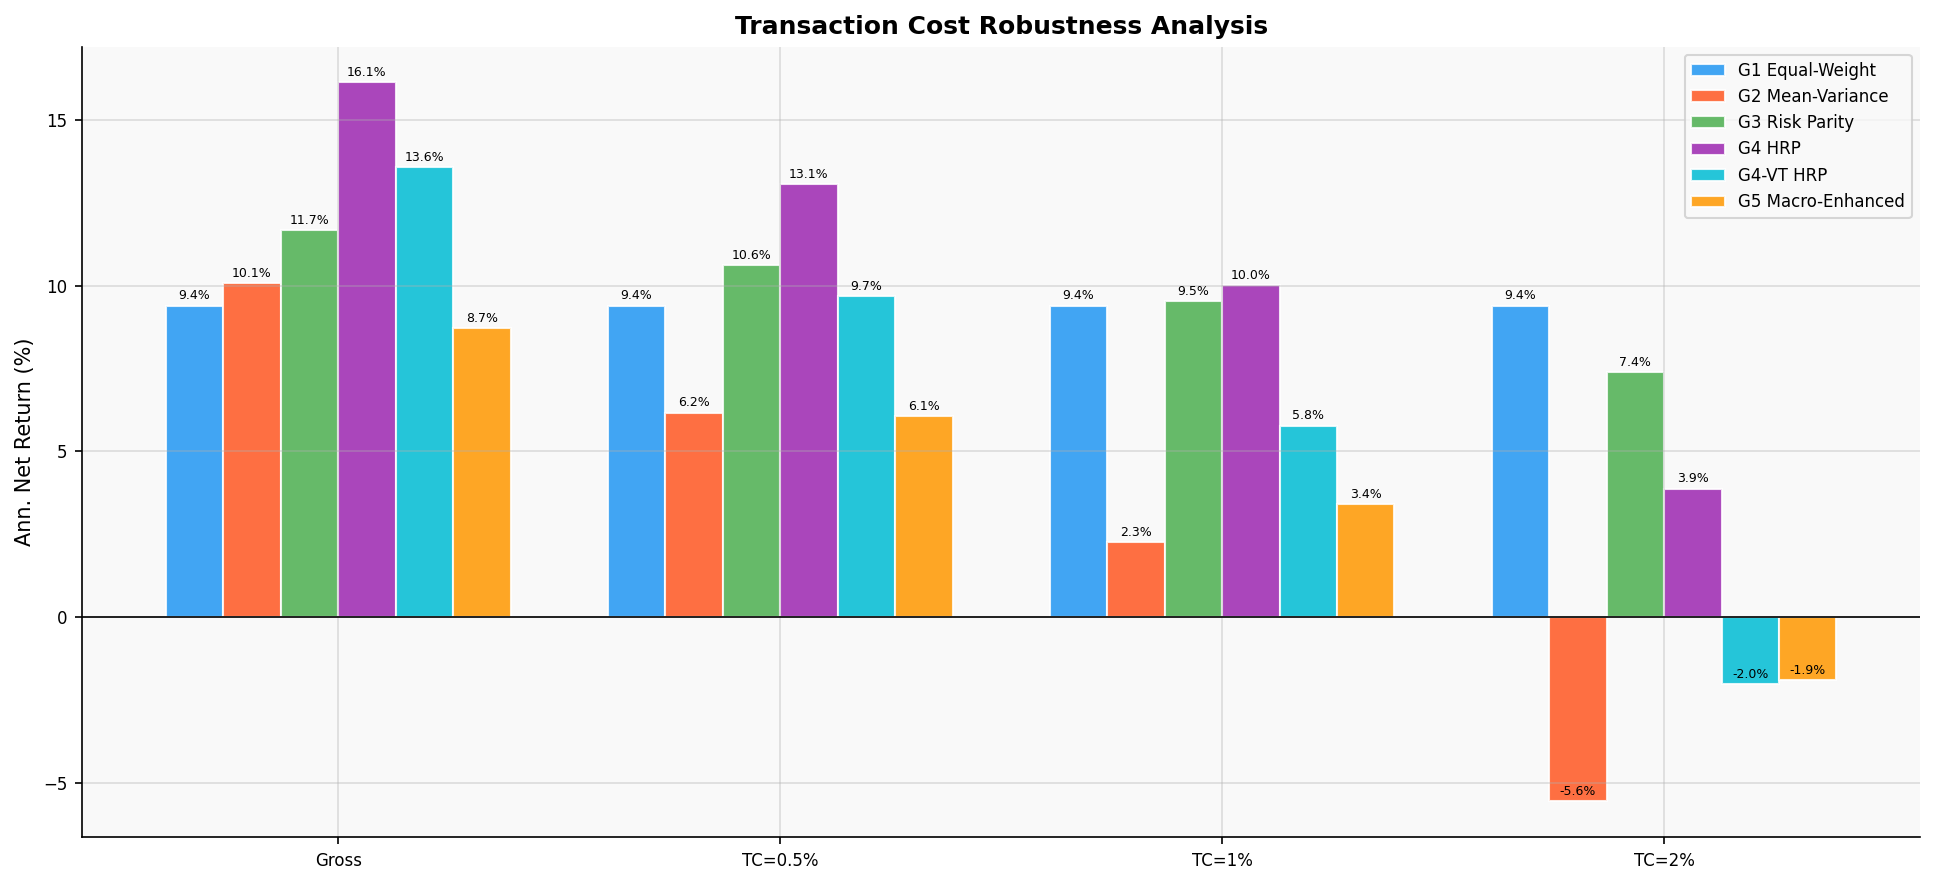

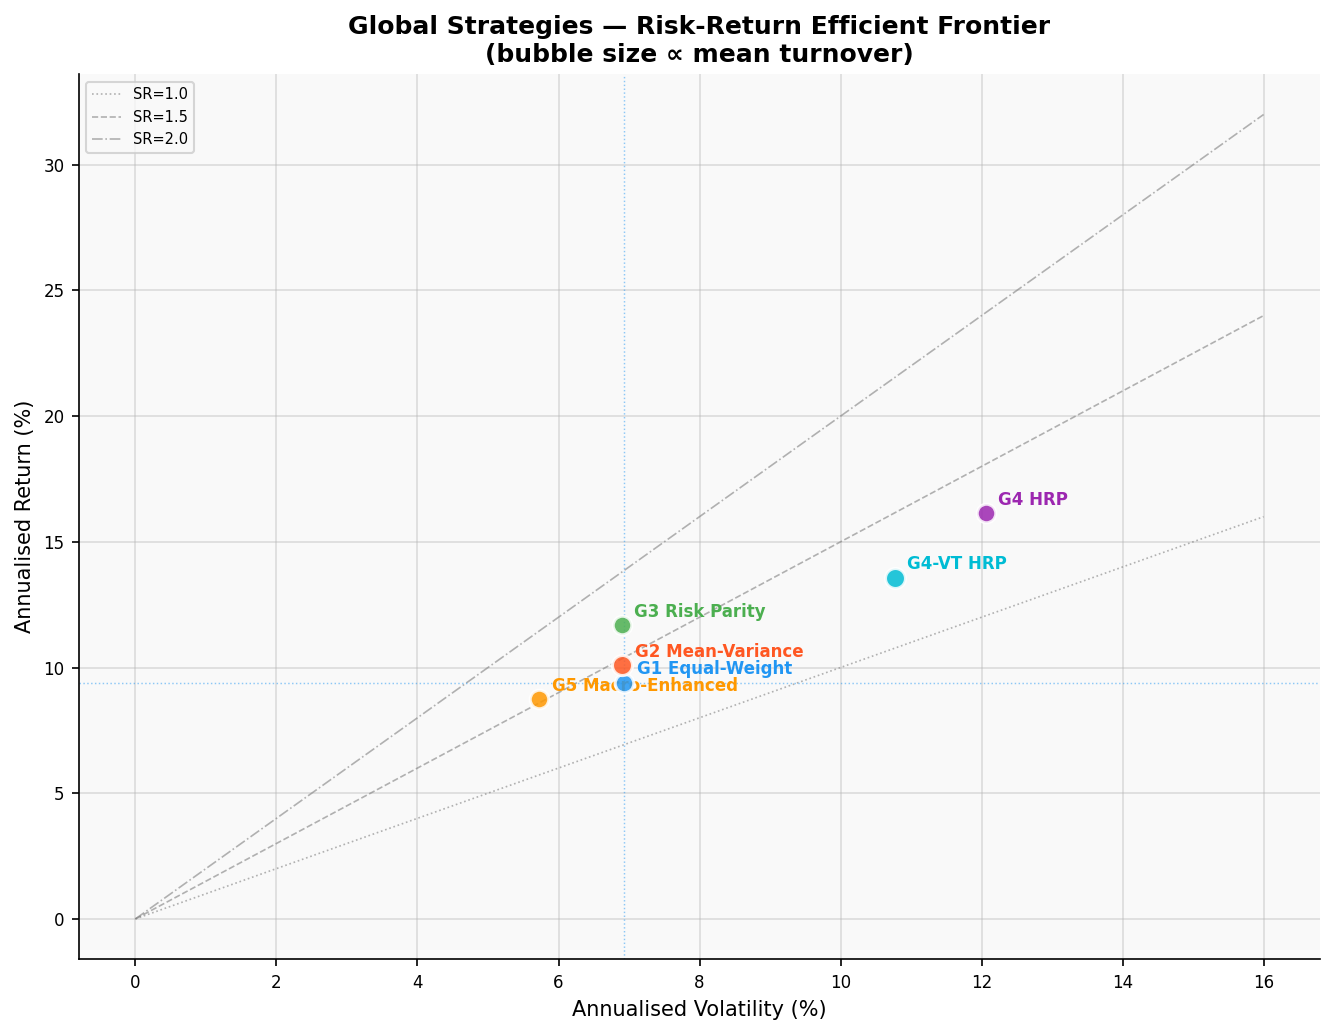

✅ Charts saved.


In [ ]:
def plot_tc_robustness(global_port_rets, global_turnovers):
    """
    Grouped bar chart showing net return under four TC scenarios.
    Bars that collapse toward zero or go negative at TC=1% are not
    viable in standard institutional environments.
    """
    cost_labels=["Gross","TC=0.5%","TC=1%","TC=2%"]
    cost_vals=[0.0,0.005,0.01,0.02]
    x=np.arange(len(cost_labels)); bw=0.13; nstr=len(global_port_rets)
    fig,ax=plt.subplots(figsize=(13,6))
    for i,(label,ret) in enumerate(global_port_rets.items()):
        tv=global_turnovers.get(label,pd.Series(0,index=ret.index))
        net_rets=[annualise_return(apply_tc(ret,tv,c))*100 for c in cost_vals]
        offset=(i-nstr/2)*bw+bw/2
        bars=ax.bar(x+offset,net_rets,bw,label=label,color=G_COLORS.get(label,"grey"),
                    alpha=0.85,edgecolor="white")
        for bar,val in zip(bars,net_rets):
            ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.1,
                    f"{val:.1f}%",ha="center",va="bottom",fontsize=6)
    ax.axhline(0,color="black",lw=0.8)
    ax.set_xticks(x); ax.set_xticklabels(cost_labels)
    ax.set_ylabel("Ann. Net Return (%)")
    ax.set_title("Transaction Cost Robustness Analysis",fontweight="bold")
    ax.legend(); plt.tight_layout()
    return _savefig(fig,"fig_tc_robustness.png")


def plot_efficient_frontier(global_port_rets, global_turnovers):
    """
    Risk-return scatter with iso-Sharpe lines at 1.0, 1.5, 2.0.
    Bubble size is proportional to mean daily turnover — larger bubble = more TC drag.
    Blue dotted lines mark G1 EW as the baseline reference.
    """
    fig,ax=plt.subplots(figsize=(9,7))
    for sr, ls in [(1.0, ":"), (1.5, "--"), (2.0, "-.")]:
        vols_range=np.linspace(0,16,200)
        ax.plot(vols_range,sr*vols_range,color="grey",lw=0.8,ls=ls,alpha=0.6,label=f"SR={sr:.1f}")
    for label,ret in global_port_rets.items():
        ann_ret=annualise_return(ret)*100; ann_vol=annualise_vol(ret)*100
        tv=global_turnovers.get(label,pd.Series(0)).mean()
        ax.scatter(ann_vol,ann_ret,s=max(tv*3000,80),color=G_COLORS.get(label,"grey"),
                   alpha=0.85,edgecolors="white",linewidth=1.5,zorder=5)
        ax.annotate(label,xy=(ann_vol,ann_ret),xytext=(6,4),
                    textcoords="offset points",fontsize=8,fontweight="bold",
                    color=G_COLORS.get(label,"grey"))
    g1_ret=list(global_port_rets.values())[0]
    ax.axhline(annualise_return(g1_ret)*100,color="#2196F3",lw=0.7,ls=":",alpha=0.5)
    ax.axvline(annualise_vol(g1_ret)*100,  color="#2196F3",lw=0.7,ls=":",alpha=0.5)
    ax.set_xlabel("Annualised Volatility (%)"); ax.set_ylabel("Annualised Return (%)")
    ax.set_title("Global Strategies — Risk-Return Efficient Frontier\n(bubble size ∝ mean turnover)",fontweight="bold")
    ax.legend(fontsize=7,loc="upper left"); plt.tight_layout()
    return _savefig(fig,"fig_efficient_frontier.png")


print("[Cell 16] TC robustness and efficient frontier charts...")
plot_tc_robustness(global_port_rets, global_turnovers)
plot_efficient_frontier(global_port_rets, global_turnovers)
print("✅ Charts saved.")


## Cell 17 · Asset-Class Breakdown & Strategy Correlations

Two diagnostic charts:

1. **Asset-class breakdown** — time-averaged allocation to Equities / Bonds / FX / Commodities per strategy. Shows that G5 Macro over-weights FX (44%) and G4/G4-VT over-weight commodities (27%) vs EW.
2. **Return correlation heatmap** — pairwise return correlations across the six strategies. G1 EW and G3 RP are nearly perfectly correlated (they use the same diversification logic). G2 MV is the most differentiated (lowest average correlation).

**Expected output:** Both charts inline.


[Cell 17] Asset class breakdown and correlation heatmap...


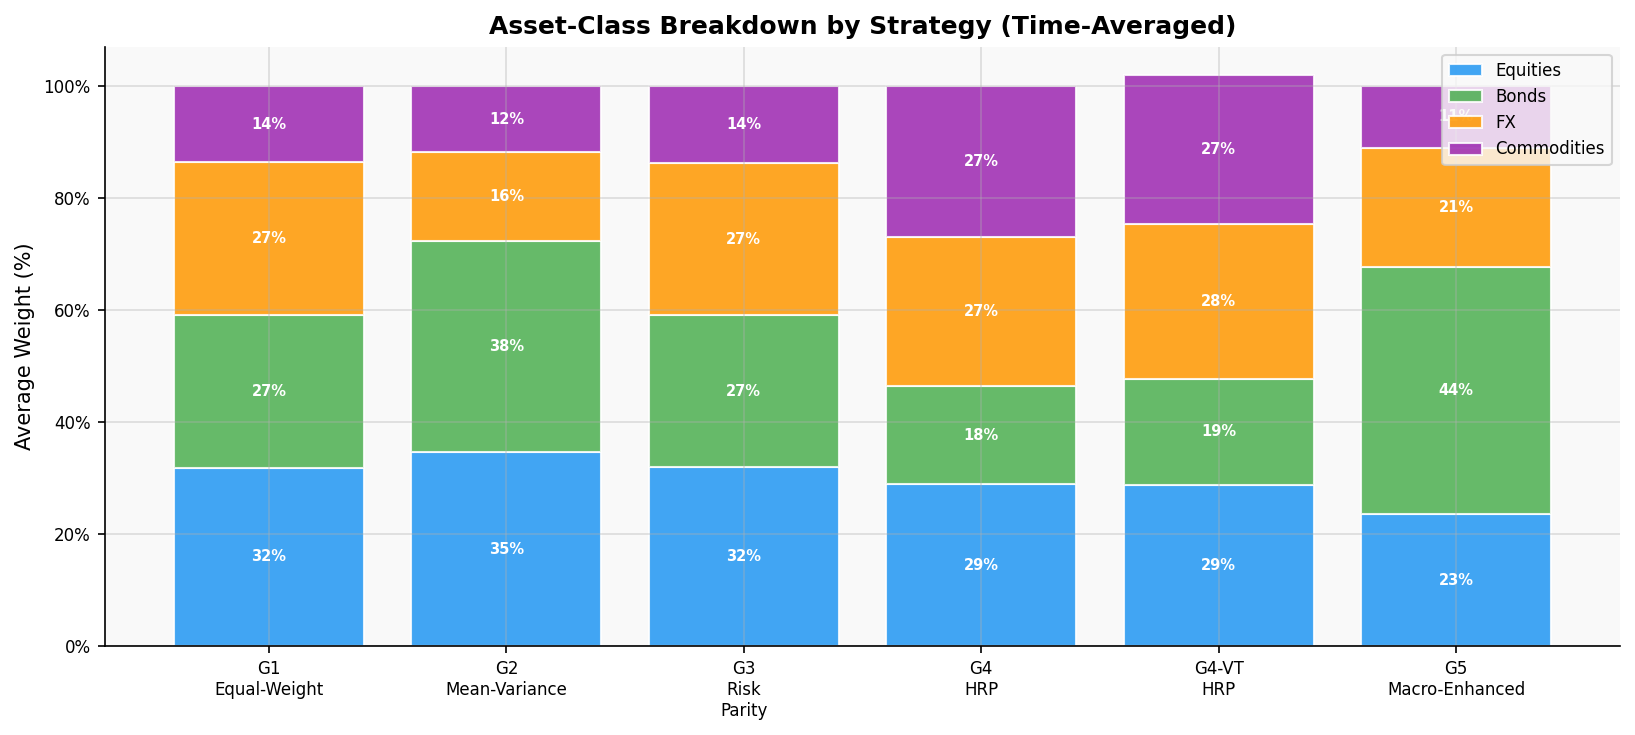

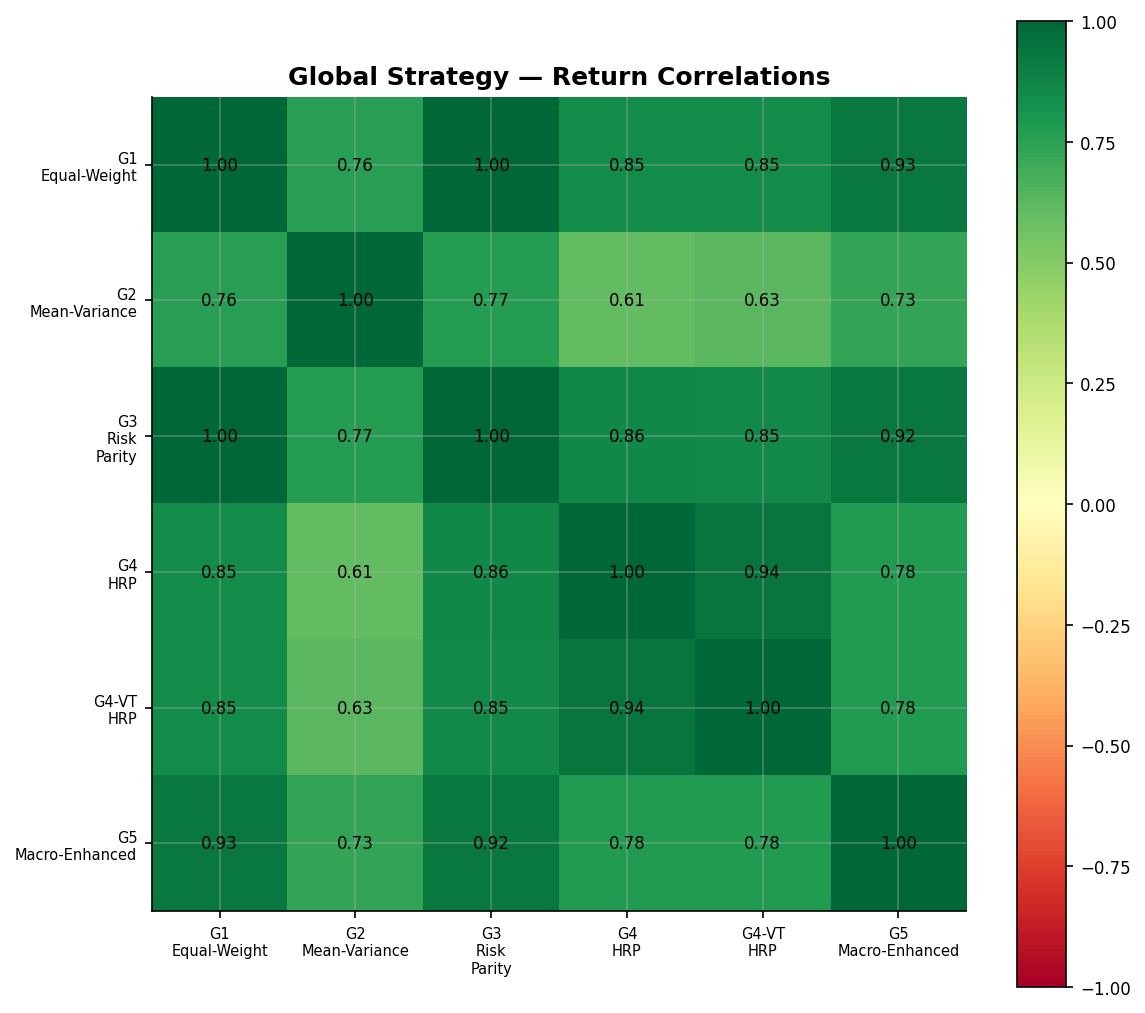

✅ Charts saved.


In [ ]:
def plot_asset_class_breakdown(global_weights):
    """Stacked bar showing time-averaged weight in each asset class per strategy."""
    ac_map=({c:"Equities" for c in EQUITY_INDICES}|{c:"Bonds" for c in BOND_COLS}|
            {c:"FX" for c in FX_COLS}|{c:"Commodities" for c in COMM_COLS})
    ac_colors={"Equities":"#2196F3","Bonds":"#4CAF50","FX":"#FF9800","Commodities":"#9C27B0"}
    classes=["Equities","Bonds","FX","Commodities"]; strategies=list(global_weights.keys())
    data=np.zeros((len(strategies),len(classes)))
    for si,strat in enumerate(strategies):
        wdf=global_weights[strat]
        for ci,cls in enumerate(classes):
            cols=[c for c in wdf.columns if ac_map.get(c)==cls]
            data[si,ci]=wdf[cols].mean().sum() if cols else 0.0
    fig,ax=plt.subplots(figsize=(11,5)); bottom=np.zeros(len(strategies))
    for ci,cls in enumerate(classes):
        bars=ax.bar(range(len(strategies)),data[:,ci],bottom=bottom,
                    label=cls,color=ac_colors[cls],alpha=0.85,edgecolor="white")
        for bi,(bar,val) in enumerate(zip(bars,data[:,ci])):
            if val>0.02:
                ax.text(bar.get_x()+bar.get_width()/2,bottom[bi]+val/2,
                        f"{val*100:.0f}%",ha="center",va="center",
                        fontsize=7,color="white",fontweight="bold")
        bottom+=data[:,ci]
    ax.set_xticks(range(len(strategies)))
    ax.set_xticklabels([s.replace(" ", "\n") for s in strategies], fontsize=8)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.set_ylabel("Average Weight (%)"); ax.legend(loc="upper right")
    ax.set_title("Asset-Class Breakdown by Strategy (Time-Averaged)",fontweight="bold")
    plt.tight_layout()
    return _savefig(fig,"fig_asset_class_breakdown.png")


def plot_strategy_correlations(global_port_rets):
    """Pairwise return correlation heatmap — green=high, red=low."""
    df=pd.DataFrame(global_port_rets).dropna(); corr=df.corr()
    fig,ax=plt.subplots(figsize=(8,7))
    im=ax.imshow(corr.values,cmap="RdYlGn",vmin=-1,vmax=1)
    plt.colorbar(im,ax=ax)
    labels = [k.replace(" ", "\n") for k in corr.columns]
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels,fontsize=7)
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels,fontsize=7)
    for i in range(len(corr)):
        for j in range(len(corr)):
            ax.text(j,i,f"{corr.values[i,j]:.2f}",ha="center",va="center",fontsize=8)
    ax.set_title("Global Strategy — Return Correlations",fontweight="bold")
    plt.tight_layout()
    return _savefig(fig,"fig_strategy_correlations.png")


print("[Cell 17] Asset class breakdown and correlation heatmap...")
plot_asset_class_breakdown(global_weights)
plot_strategy_correlations(global_port_rets)
print("✅ Charts saved.")


## Cell 18 · Monthly Return Heatmap

A year × month grid for each strategy — green cells are positive months, red are negative.

This is the most useful single chart for spotting regime behaviour at a glance:
- The March 2020 column is red for every strategy (COVID drawdown)
- G2 MV's red cells are visually lighter — confirming its drawdown resilience
- G4 HRP has the widest colour range month-to-month — highest variance

**Expected output:** Six heatmap panels stacked vertically, one per strategy.


[Cell 18] Monthly return heatmap (6 panels)...


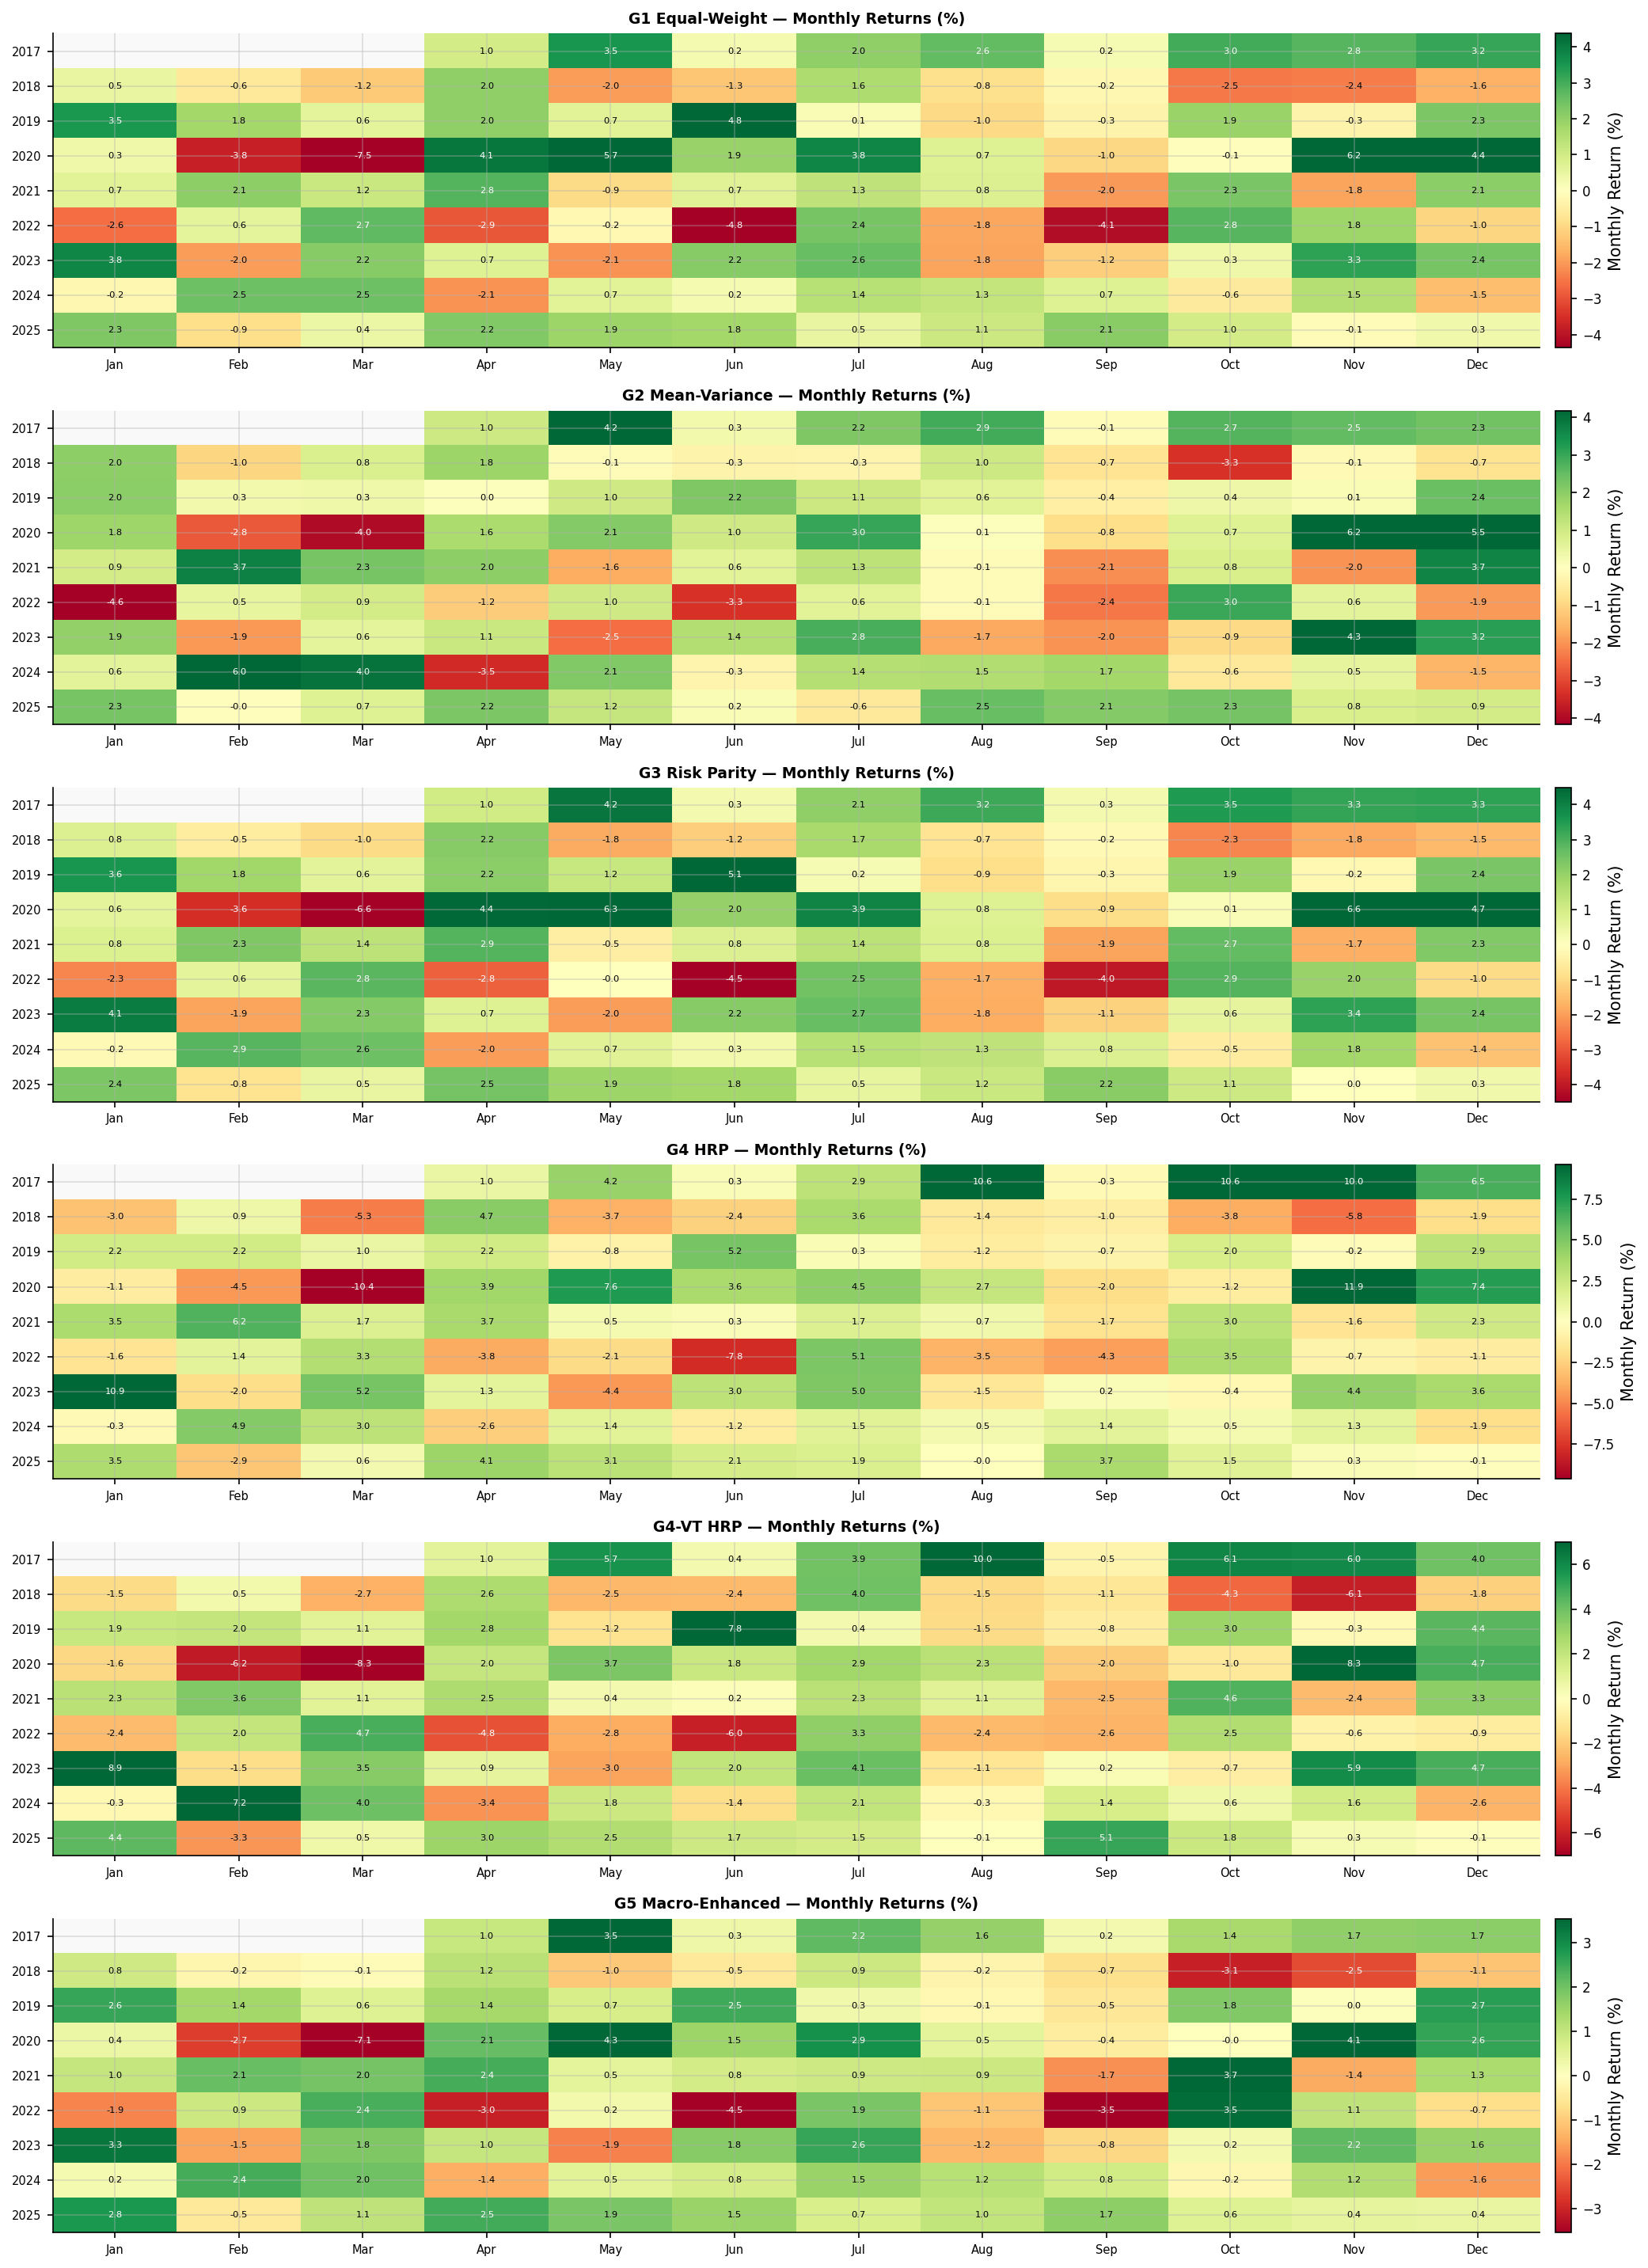

✅ Heatmap saved.


In [ ]:
def plot_monthly_heatmap(global_port_rets):
    """
    Year × Month return grid for all six strategies.
    Colour scale is symmetric: symmetric vmax = 95th percentile of |returns|.
    Cell values shown in % (e.g. '3.2' means +3.2%).
    """
    month_abbr=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
    n_strats=len(global_port_rets)
    fig,axes=plt.subplots(n_strats,1,figsize=(14,3.2*n_strats))
    if n_strats==1: axes=[axes]
    for ax,(label,ret) in zip(axes,global_port_rets.items()):
        monthly=(1+ret).resample("MS").prod()-1
        df_m=monthly.to_frame("r"); df_m["year"]=df_m.index.year; df_m["month"]=df_m.index.month
        years=sorted(df_m["year"].unique())
        grid=np.full((len(years),12),np.nan)
        for _,row in df_m.iterrows():
            grid[years.index(row["year"]),int(row["month"])-1]=row["r"]*100
        vmax=np.nanpercentile(np.abs(grid),95)
        im=ax.imshow(grid,cmap="RdYlGn",vmin=-vmax,vmax=vmax,aspect="auto")
        for yi in range(len(years)):
            for mi in range(12):
                val=grid[yi,mi]
                if not np.isnan(val):
                    ax.text(mi,yi,f"{val:.1f}",ha="center",va="center",fontsize=5.5,
                            color="black" if abs(val)<vmax*0.6 else "white")
        ax.set_xticks(range(12)); ax.set_xticklabels(month_abbr,fontsize=7)
        ax.set_yticks(range(len(years))); ax.set_yticklabels(years,fontsize=7)
        ax.set_title(f"{label} — Monthly Returns (%)",fontweight="bold",fontsize=9)
        plt.colorbar(im,ax=ax,fraction=0.02,pad=0.01,label="Monthly Return (%)")
    plt.tight_layout()
    return _savefig(fig,"fig_monthly_heatmap.png")


print("[Cell 18] Monthly return heatmap (6 panels)...")
plot_monthly_heatmap(global_port_rets)
print("✅ Heatmap saved.")


## Cell 19 · Vol-Targeting Leverage & Weight Allocation Charts

**G4-VT leverage chart:** Shows the daily leverage factor applied by the vol-targeting overlay.
- Green fill = leveraged above 1× (low-vol periods, 2017-2019)
- Red fill = de-leveraged below 1× (high-vol periods, March 2020 COVID crash)

**Weight allocation charts:** One chart per strategy with two panels:
- Left panel: equity index weights over time
- Right panel: bond / FX / commodity weights over time

**Expected output:** Leverage chart + 6 weight allocation charts, all saved.


[Cell 19] Leverage chart and weight allocation charts...


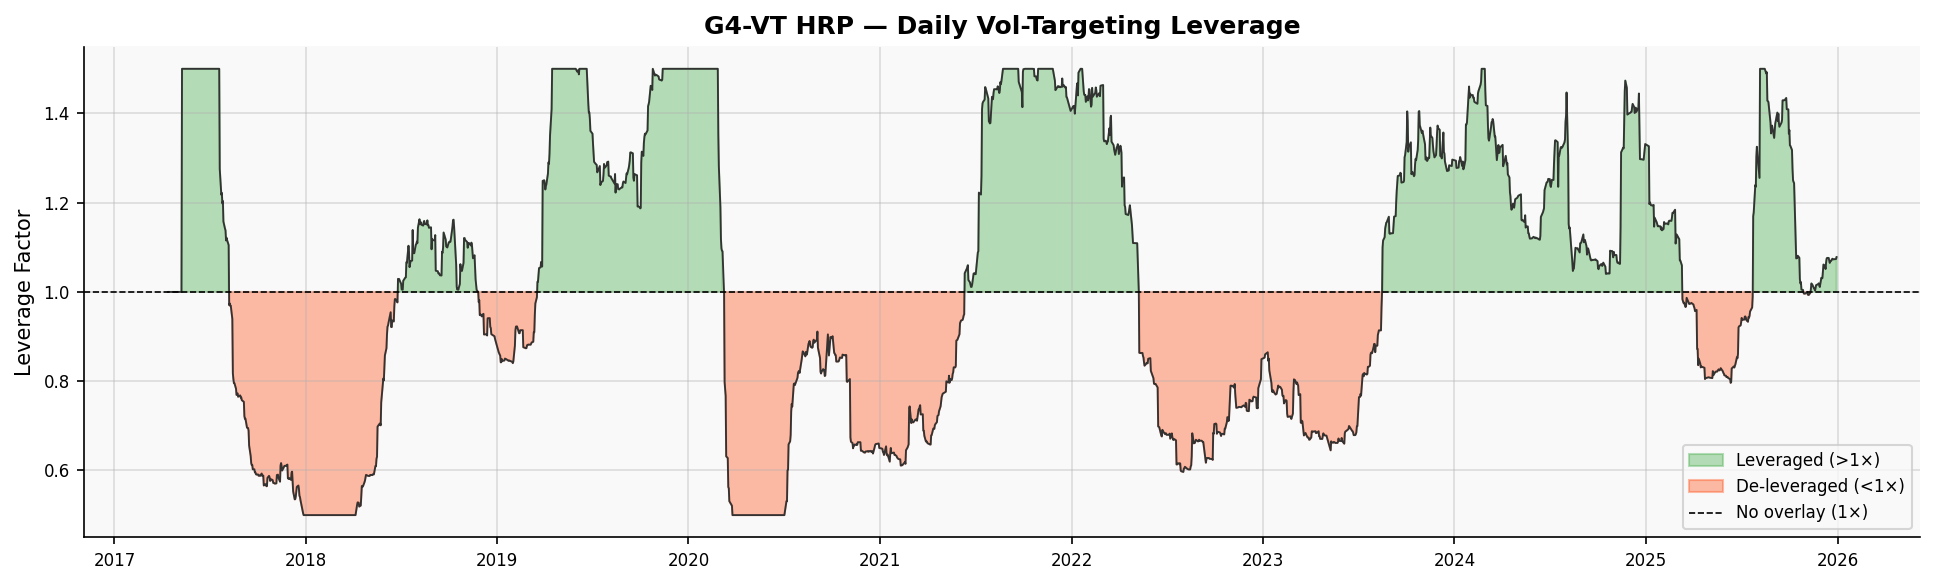

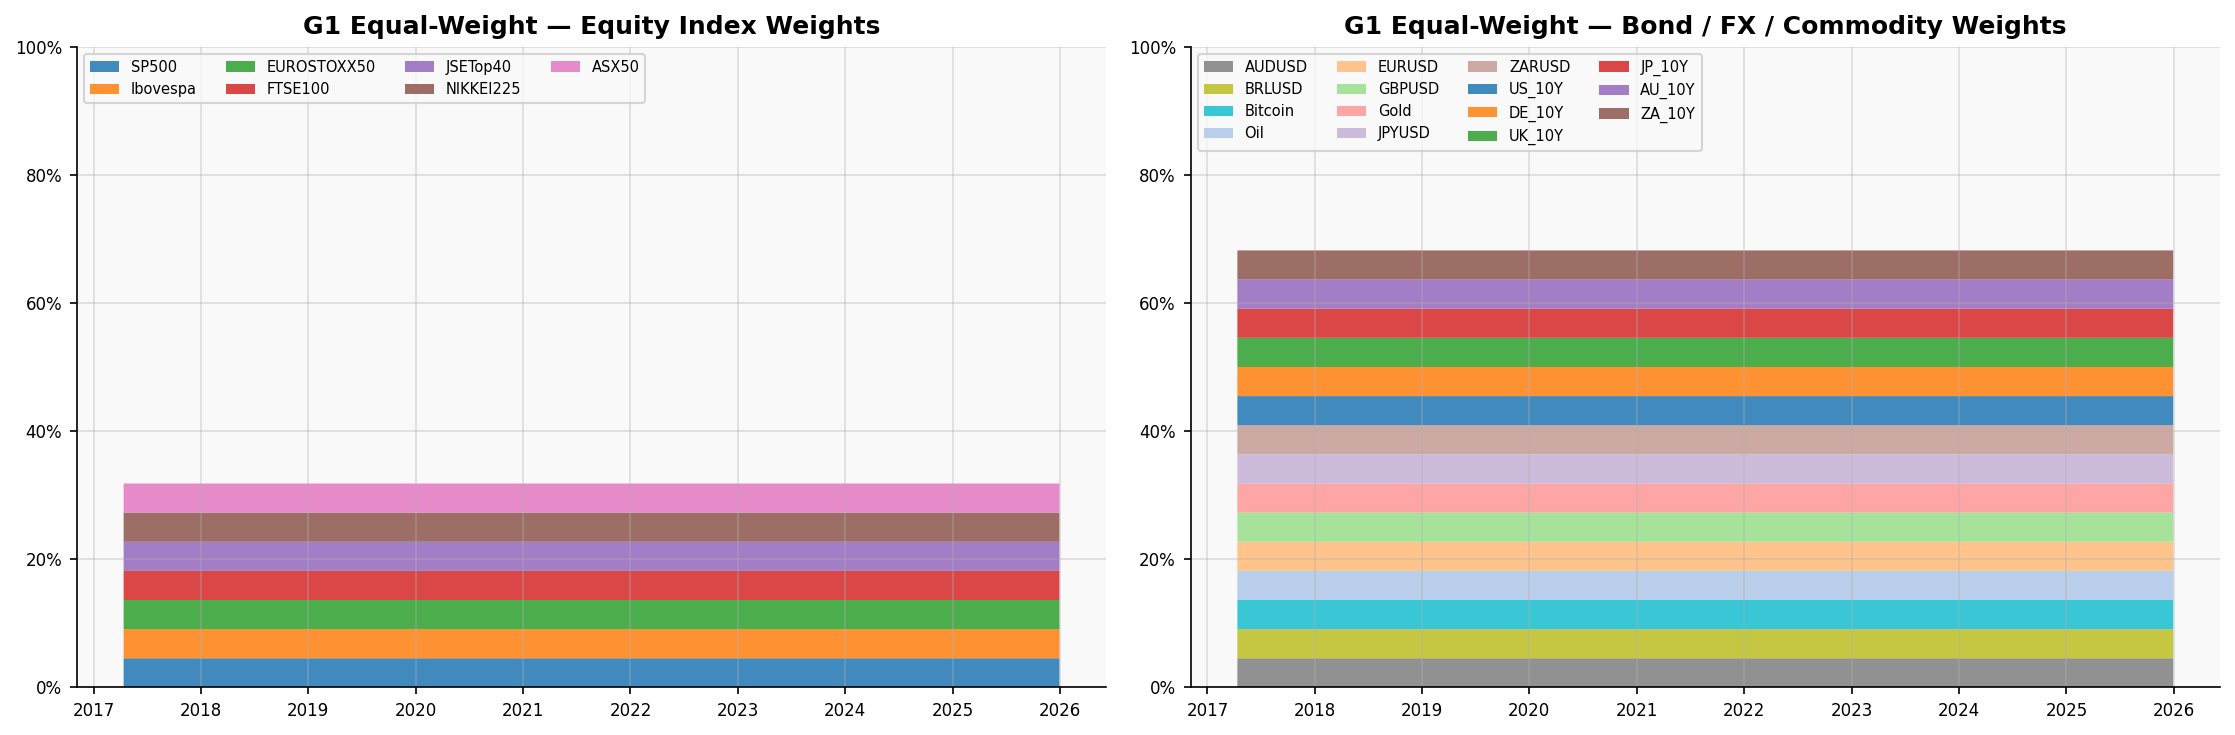

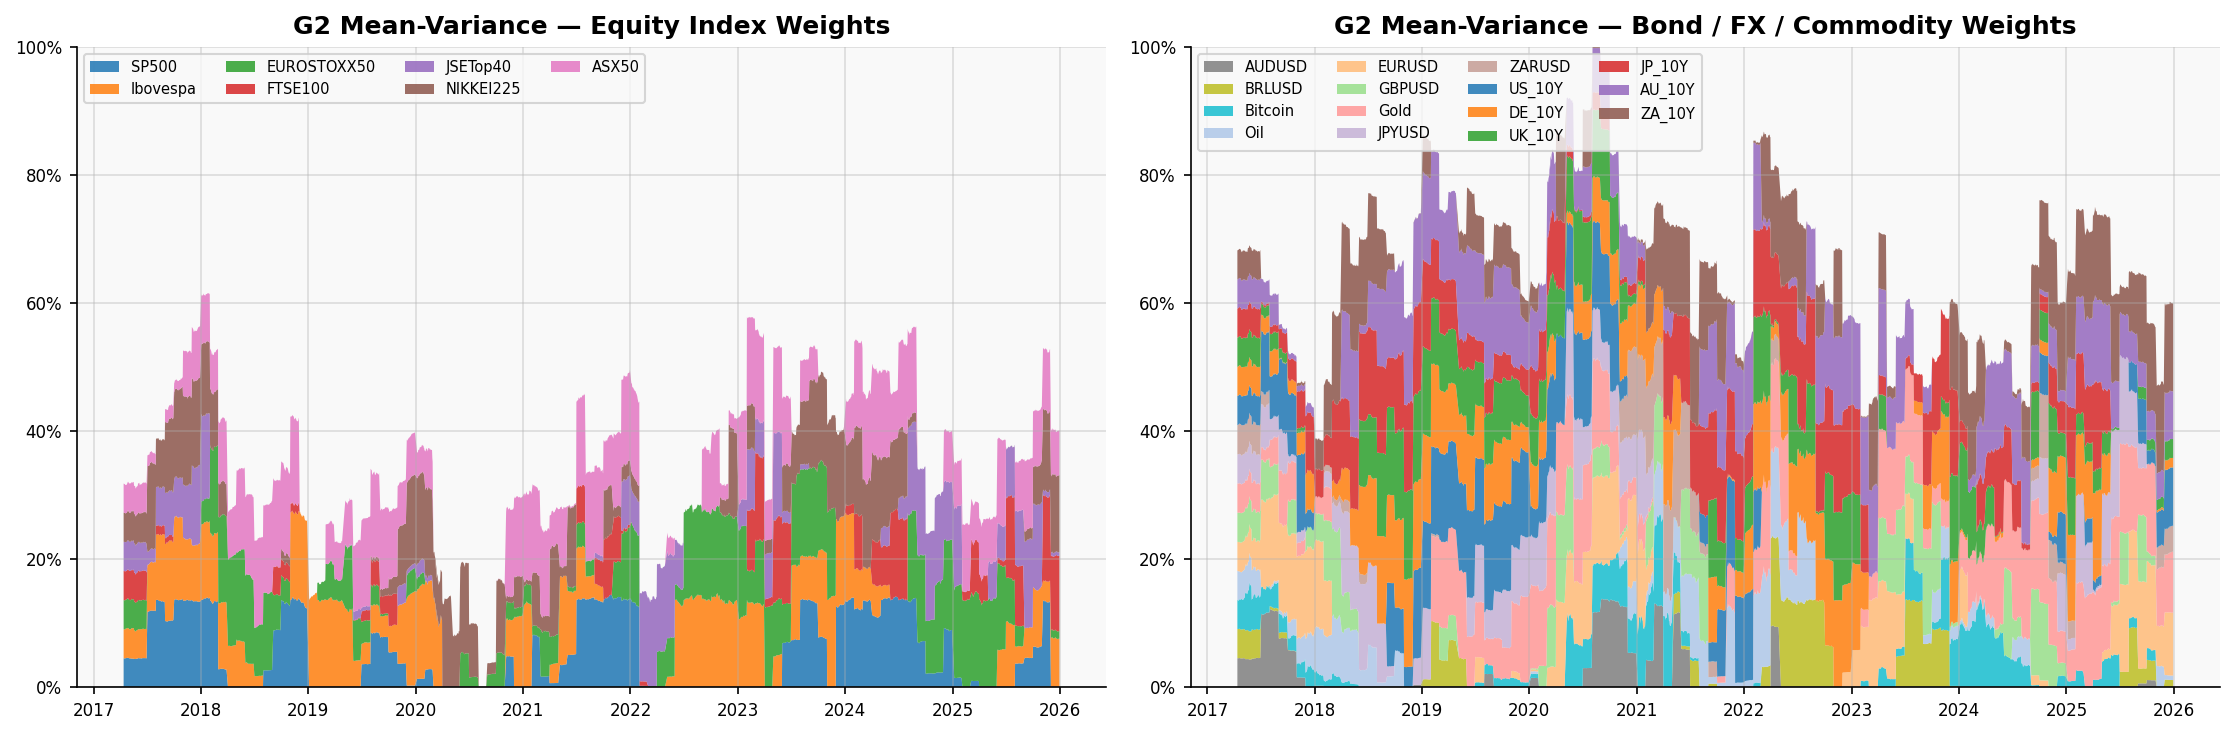

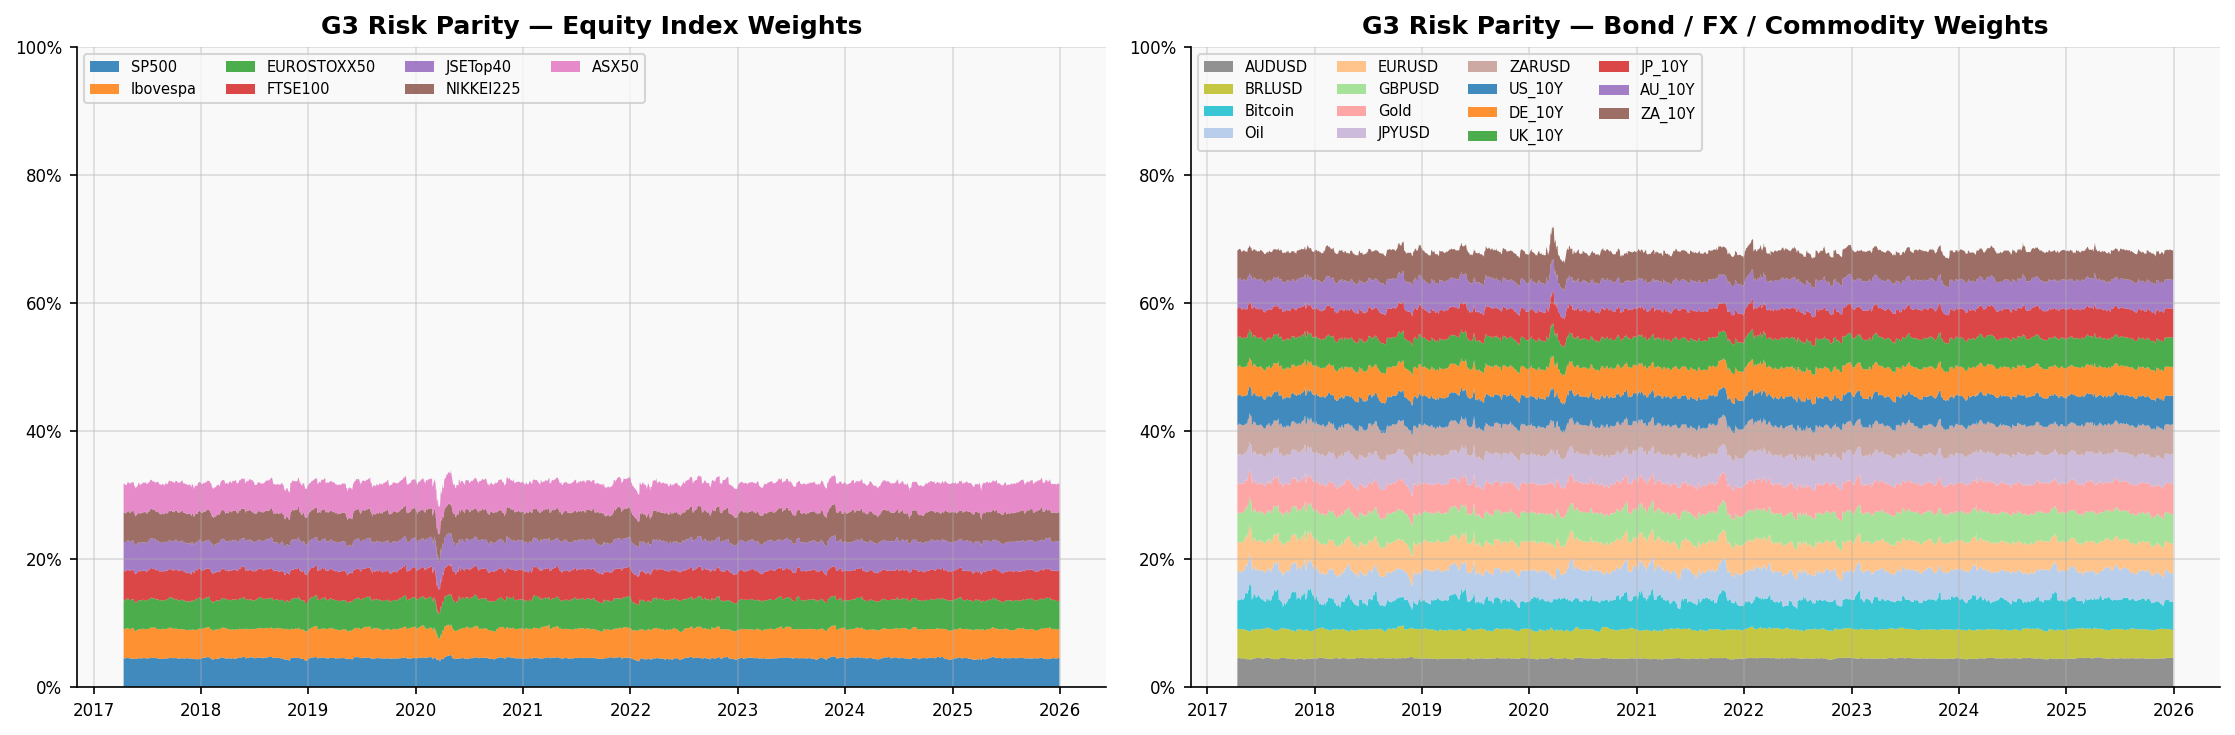

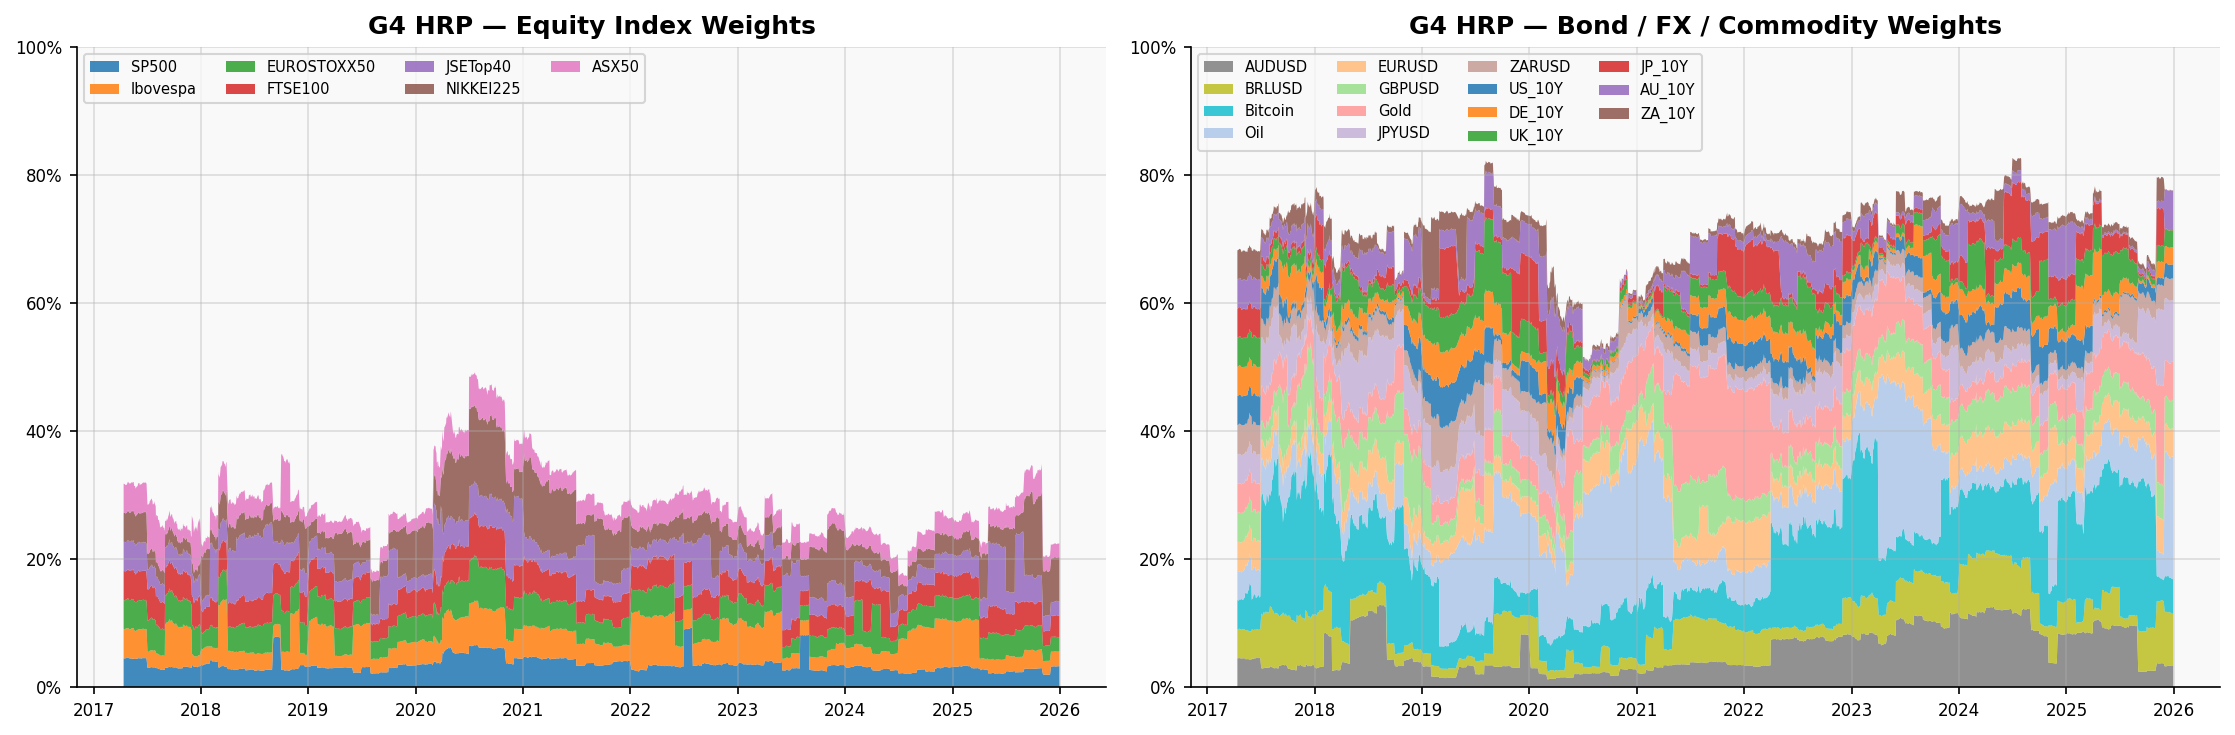

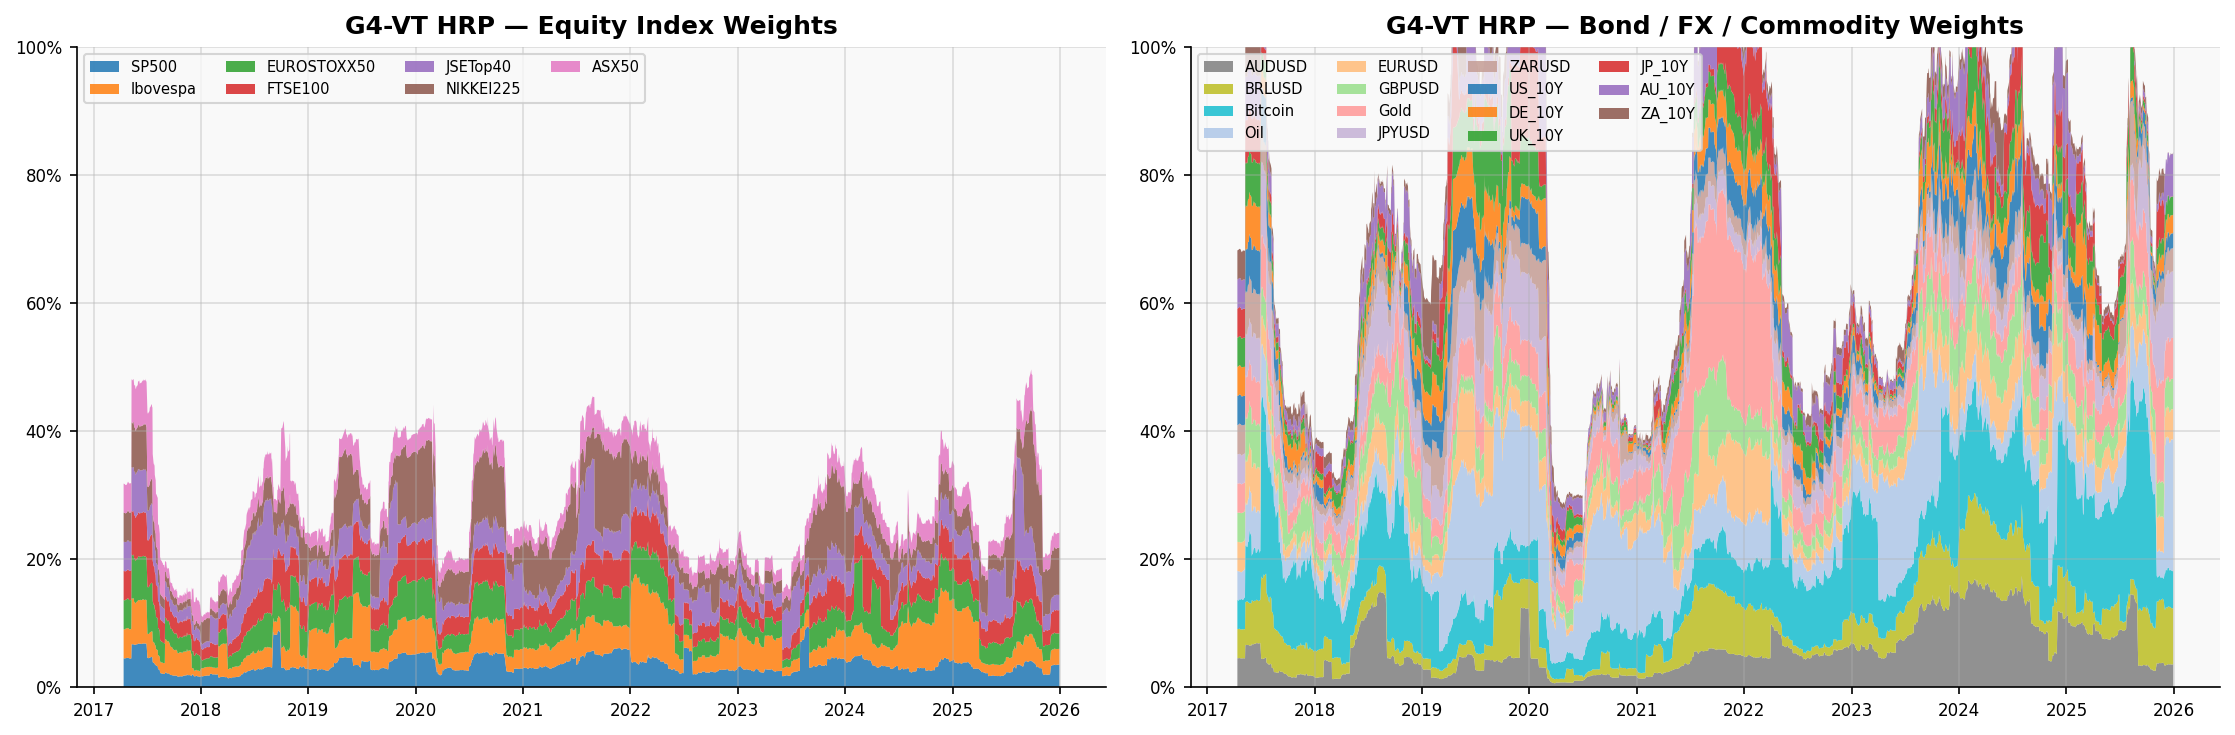

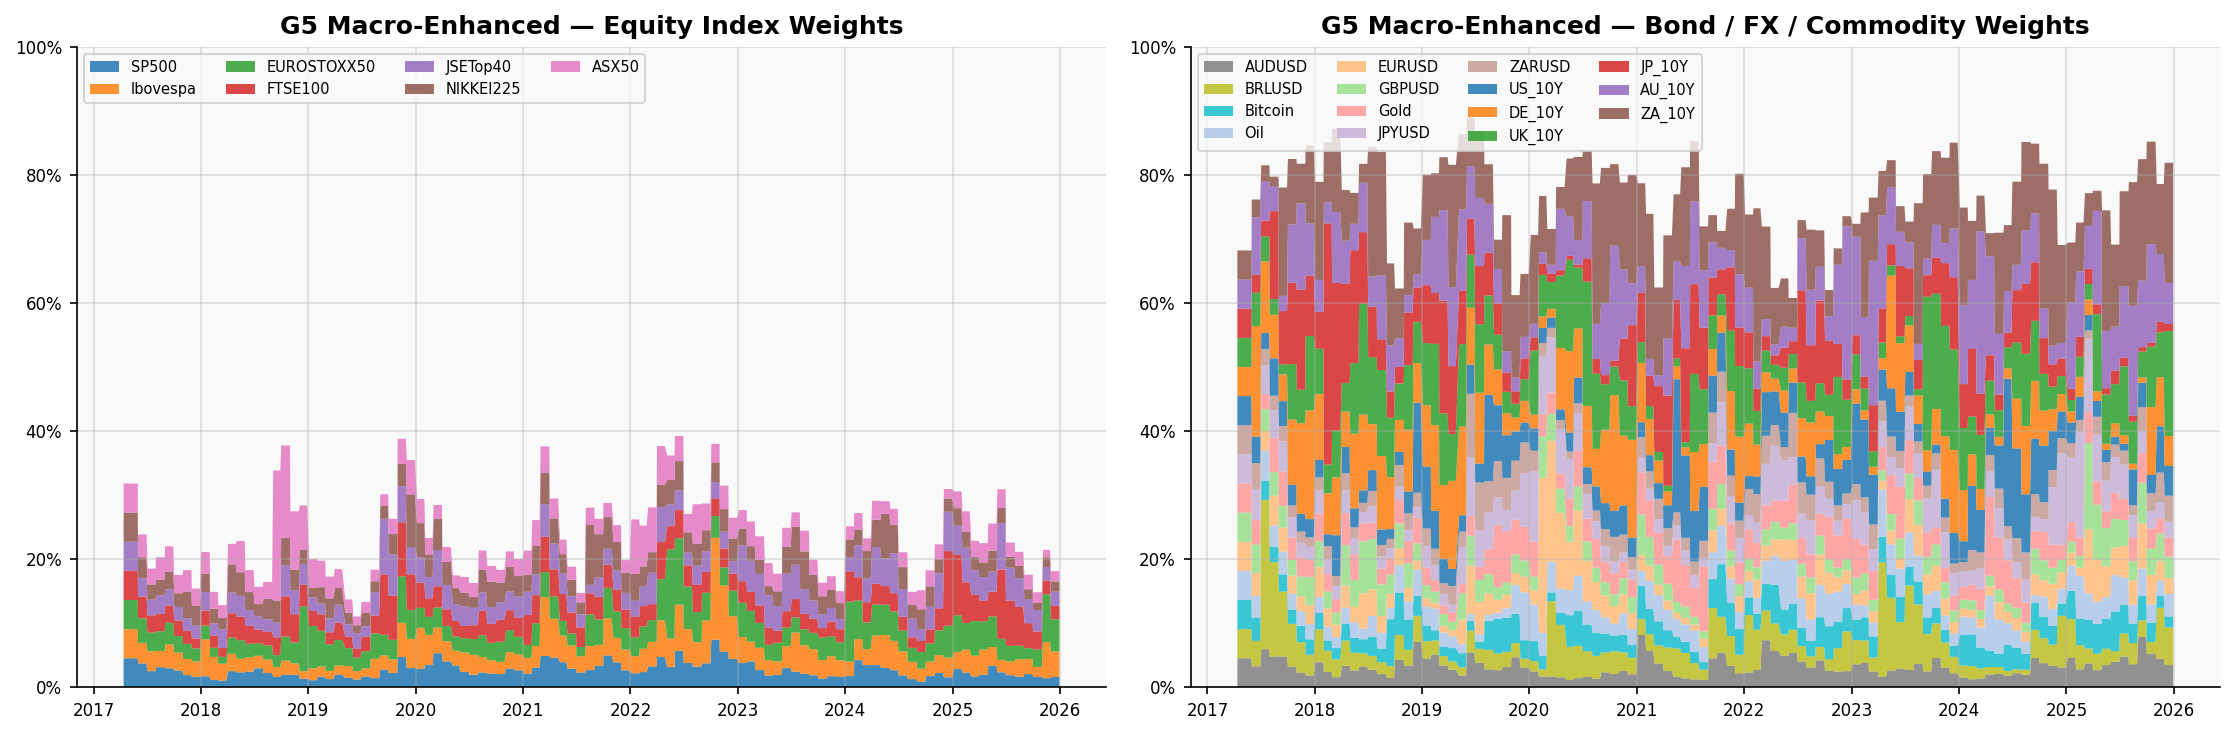

✅ All weight charts saved.


In [ ]:
def plot_leverage(leverages, label="G4-VT HRP"):
    """
    Daily leverage factor for the vol-targeting overlay.
    Green = leveraged (1×+), red = de-leveraged (below 1×).
    The COVID shock (Mar 2020) should be clearly visible as a sharp drop to 0.5×.
    """
    fig,ax=plt.subplots(figsize=(13,4))
    ax.fill_between(leverages.index,leverages.values,1.0,
                    where=leverages.values>=1.0,alpha=0.4,color="#4CAF50",label="Leveraged (>1×)")
    ax.fill_between(leverages.index,leverages.values,1.0,
                    where=leverages.values<1.0, alpha=0.4,color="#FF5722",label="De-leveraged (<1×)")
    ax.plot(leverages.index,leverages.values,color="#333333",lw=0.9)
    ax.axhline(1.0,color="black",lw=0.8,ls="--",label="No overlay (1×)")
    ax.set_ylabel("Leverage Factor")
    ax.set_title(f"{label} — Daily Vol-Targeting Leverage",fontweight="bold")
    ax.legend(fontsize=8); plt.tight_layout()
    return _savefig(fig,"fig_g4_leverage.png")


def plot_weight_allocation(label, weights_df):
    """
    Stacked area chart split into equity (left) and macro (right) panels.
    Stable weights = low turnover strategy; highly variable = high TC strategy.
    """
    cols=weights_df.columns.tolist()
    eq_cols=[c for c in cols if c in EQUITY_INDICES]
    mc_cols=[c for c in cols if c not in EQUITY_INDICES]
    has_mc=len(mc_cols)>0
    fig,axes=plt.subplots(1,2 if has_mc else 1,figsize=(15 if has_mc else 8,5))
    if not has_mc: axes=[axes]
    def _sp(ax,sel_cols,offset,title):
        pal=[IDX_COLORS[(i+offset)%len(IDX_COLORS)] for i in range(len(sel_cols))]
        ax.stackplot(weights_df.index,[weights_df[c].values for c in sel_cols],
                     labels=sel_cols,colors=pal,alpha=0.85)
        ax.set_ylim(0,1); ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
        ax.set_title(title,fontweight="bold"); ax.legend(loc="upper left",ncol=4,fontsize=7)
    if eq_cols: _sp(axes[0],eq_cols,0,f"{label} — Equity Index Weights")
    if has_mc:  _sp(axes[1],mc_cols,7,f"{label} — Bond / FX / Commodity Weights")
    plt.tight_layout()
    safe=label.lower().replace(" ","_").replace("/","")
    return _savefig(fig,f"fig_weights_{safe}.png")


print("[Cell 19] Leverage chart and weight allocation charts...")
plot_leverage(g4vt_lev, "G4-VT HRP")
for label,wdf in global_weights.items():
    plot_weight_allocation(label, wdf)
print("✅ All weight charts saved.")


## Cell 20 · Final Summary & Output Index

Lists all files generated by the notebook and prints a compact performance comparison table for quick reference.

**Expected output:**  
1. Full file list with sizes  
2. Compact ranked table — strategies sorted by Sharpe Ratio


In [ ]:
print("=" * 70)
print("  TWO-LEVEL GLOBAL PORTFOLIO FRAMEWORK  v3 — COMPLETE")
print("  Universe: 22 assets | Study period: 2015-2025")
print("=" * 70)

# ── List all output files ─────────────────────────────────────────────────────
import glob
output_files = sorted(glob.glob(f"{OUTPUT_DIR}/*"))
print(f"\n📁 Output directory: {os.path.abspath(OUTPUT_DIR)}")
print(f"   {len(output_files)} files generated:\n")
for fpath in output_files:
    size_kb=os.path.getsize(fpath)/1024
    print(f"   {'📊' if fpath.endswith('.csv') else '📈'} {os.path.basename(fpath):45s}  {size_kb:6.1f} KB")

# ── Compact performance summary ───────────────────────────────────────────────
print("\n" + "─"*70)
print("  QUICK REFERENCE — Level-2 Strategies Ranked by Sharpe Ratio")
print("─"*70)
quick = g_summary[["Strategy","Ann. Return (%)","Ann. Volatility (%)","Sharpe Ratio",
                    "Max Drawdown (%)","Mean Turnover","Net Ret TC=1.0% (%)"]].copy()
quick = quick.sort_values("Sharpe Ratio", ascending=False).reset_index(drop=True)
quick.index = quick.index + 1   # rank from 1
display(quick.style
    .format({"Ann. Return (%)":"{:.2f}","Ann. Volatility (%)":"{:.2f}",
             "Sharpe Ratio":"{:.3f}","Max Drawdown (%)":"{:.2f}",
             "Mean Turnover":"{:.4f}","Net Ret TC=1.0% (%)":"{:.2f}"})
    .background_gradient(subset=["Sharpe Ratio"],cmap="RdYlGn")
    .set_caption("Final ranking by Sharpe Ratio"))

print("\n  Recommendation: G3 Risk Parity — highest Sharpe, lowest turnover,")
print("  TC-robust, and consistent across all three market regimes.")


  TWO-LEVEL GLOBAL PORTFOLIO FRAMEWORK  v3 — COMPLETE
  Universe: 22 assets | Study period: 2015-2025

📁 Output directory: /content/outputs
   22 files generated:

   📈 fig_asset_class_breakdown.png                    71.4 KB
   📈 fig_efficient_frontier.png                      116.3 KB
   📈 fig_g4_leverage.png                             122.0 KB
   📈 fig_global_cumulative.png                       260.6 KB
   📈 fig_global_drawdowns.png                        334.2 KB
   📈 fig_global_rolling_sharpe.png                   318.0 KB
   📈 fig_l1_cumulative.png                           740.6 KB
   📈 fig_l1_sharpe.png                                67.4 KB
   📈 fig_monthly_heatmap.png                         465.0 KB
   📈 fig_regime_analysis.png                          83.5 KB
   📈 fig_rolling_vol.png                             281.7 KB
   📈 fig_strategy_correlations.png                    79.5 KB
   📈 fig_tc_robustness.png                            63.1 KB
   📈 fig_weights_g1_equal-weig

,Strategy,Ann. Return (%),Ann. Volatility (%),Sharpe Ratio,Max Drawdown (%),Mean Turnover,Net Ret TC=1.0% (%)
1,G3 Risk Parity,11.69,6.90,1.695,-14.26,0.0085,9.54
2,G5 Macro-Enhanced,8.73,5.72,1.525,-13.56,0.0211,3.41
3,G2 Mean-Variance,10.08,6.90,1.460,-9.95,0.0311,2.26
4,G1 Equal-Weight,9.40,6.94,1.355,-15.21,0.0000,9.40
5,G4 HRP,16.14,12.06,1.339,-26.10,0.0243,10.01
6,G4-VT HRP,13.58,10.77,1.260,-19.79,0.0309,5.78



  Recommendation: G3 Risk Parity — highest Sharpe, lowest turnover,
  TC-robust, and consistent across all three market regimes.
